# Quickstart: From Parametric to Bursty SFH Recovery

This notebook demonstrates the full diffsed workflow in two parts:

- **Part A**: Parametric SFH ($D = 7$) — smooth double power law,
  EVI + NUTS cross-validation.
- **Part B**: Stochastic SFH ($D \approx 137$) — GP correlated field
  with PSD-governed burstiness, EVI + NUTS comparison.

Each part follows the same pattern: generate mock → run EVI →
run NUTS → compare posteriors and SFH recovery.

## Setup

In [1]:
import time
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

from diffsed import (
    Model, ParamSpec, Uniform, Fixed, Fitter,
    load_ssp_data, load_filter_set,
)
from diffsed.plotting import plot_corner_comparison

import sys; sys.path.insert(0, ".")
from _plot_style import setup_style, COLORS, SDSS_WAVE_EFF, SDSS_BAND_NAMES
from _plot_style import convergence_table
setup_style()

import os; os.makedirs("notebook_figures", exist_ok=True)

ssp_data = load_ssp_data(
    "../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
)
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
print(f"SSP grid: {len(ssp_data.ssp_lgmet)} metallicities x "
      f"{len(ssp_data.ssp_lg_age_gyr)} ages")

# Observed wavelength grid for background spectrum
wave_spec = np.linspace(3000, 10500, 500)

SSP grid: 15 metallicities x 93 ages


In [2]:
# ---------- Reusable plotting helpers ----------

PHYS_PARAMS = [
    "sfh_dpl_alpha", "sfh_dpl_beta", "sfh_dpl_tau_gyr", "sfh_dpl_log_peak_sfr",
    "met_logzsol", "dust_tau_bc", "dust_tau_diff",
]

PHYS_PARAMS_STOCH = PHYS_PARAMS + ["sfh_field_psd_sigma", "sfh_field_psd_tau_myr"]


def plot_mock(model, mock, true_params, title="Mock Photometry"):
    """Plot mock photometry with background spectrum."""
    spec_true = np.array(model.predict_spectrum(true_params, wave_spec))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(wave_spec, spec_true, color="0.75", lw=0.6, alpha=0.7,
            label="Model spectrum")
    ax.errorbar(SDSS_WAVE_EFF, mock.flux_obs, yerr=mock.noise,
                fmt="o", ms=8, color="k", capsize=4, capthick=1.2,
                elinewidth=1.2, zorder=10, label="Mock photometry (SNR 20)")
    ax.scatter(SDSS_WAVE_EFF, mock.flux_true, marker="D", s=50,
               facecolors="none", edgecolors="C3", linewidths=1.5,
               zorder=11, label="Truth (noiseless)")
    ax.set_xlabel(r"Observed wavelength [$\AA$]")
    ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
    ax.set_xlim(2500, 11000)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    return fig


def plot_sfh_with_inset(t_gyr, sfr_list, labels, colors, styles,
                        title="SFH", sfr_mean=None):
    """Plot SFH with inset for last 200 Myr.

    sfr_list: list of (sfr_array,) or (lo, median, hi) tuples.
    """
    fig, ax = plt.subplots(figsize=(9, 4.5))

    for sfr_data, label, color, style in zip(sfr_list, labels, colors, styles):
        if len(sfr_data) == 1:
            # Single line
            ax.plot(t_gyr, sfr_data[0], color=color, lw=style.get("lw", 2),
                    ls=style.get("ls", "-"), alpha=style.get("alpha", 1),
                    label=label, zorder=style.get("zorder", 5))
        elif len(sfr_data) == 3:
            # Band: lo, median, hi
            lo, med, hi = sfr_data
            ax.fill_between(t_gyr, lo, hi, color=color, alpha=0.2)
            ax.plot(t_gyr, med, color=color, lw=1.5, label=label,
                    zorder=style.get("zorder", 5))

    if sfr_mean is not None:
        ax.plot(t_gyr, sfr_mean, color="k", lw=1, ls=":", alpha=0.4,
                label="Secular mean")

    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$ yr$^{-1}$]")
    ax.set_xlim(0, 13.5)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9, loc="upper left")
    ax.set_title(title)

    # Inset: last 200 Myr
    axins = inset_axes(ax, width="30%", height="40%", loc="upper right",
                       borderpad=2.5)
    mask = t_gyr <= 0.2
    t_myr = t_gyr[mask] * 1e3
    for sfr_data, label, color, style in zip(sfr_list, labels, colors, styles):
        if len(sfr_data) == 1:
            axins.plot(t_myr, sfr_data[0][mask], color=color,
                       lw=style.get("lw", 2), ls=style.get("ls", "-"),
                       alpha=style.get("alpha", 1))
        elif len(sfr_data) == 3:
            lo, med, hi = sfr_data
            axins.fill_between(t_myr, lo[mask], hi[mask],
                               color=color, alpha=0.2)
            axins.plot(t_myr, med[mask], color=color, lw=1.5)
    axins.set_xlabel("Lookback [Myr]", fontsize=8)
    axins.set_ylabel("SFR", fontsize=8)
    axins.tick_params(labelsize=7)
    axins.set_xlim(0, 200)
    axins.set_ylim(bottom=0)
    axins.set_title("Last 200 Myr", fontsize=8)

    return fig


def plot_phot_fit(model, mock, result, color, title="Photometry Fit"):
    """Photometry fit with spectrum background and residuals."""
    n_samp = result.diagnostics.get("n_samples",
                len(next(iter(result.samples.values()))) if result.samples else 0)
    n_pred = min(200, n_samp)
    idx = np.linspace(0, n_samp - 1, n_pred, dtype=int)
    pred_fluxes = []
    for i in idx:
        params_i = {k: result.samples[k][i] for k in result.samples}
        pred = model.predict_photometry(params_i)
        pred_fluxes.append(np.array(pred))
    pred_fluxes = np.array(pred_fluxes)
    pred_median = np.median(pred_fluxes, axis=0)

    # Spectrum from the MAP/median params
    spec_model = np.array(model.predict_spectrum(result.params, wave_spec))

    fig = plt.figure(figsize=(9, 5.5))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    # Spectrum background
    ax1.plot(wave_spec, spec_model, color=color, lw=0.6, alpha=0.4,
             label="Model spectrum")

    # Posterior photometry draws
    for draw in pred_fluxes[::max(1, n_pred // 50)]:
        ax1.plot(SDSS_WAVE_EFF, draw, "o-", color=color, alpha=0.04,
                 ms=3, lw=0.6)

    # Data + model median
    ax1.errorbar(SDSS_WAVE_EFF, mock.flux_obs, yerr=mock.noise,
                 fmt="o", ms=8, color="k", capsize=4, zorder=10,
                 label="Observed")
    ax1.plot(SDSS_WAVE_EFF, pred_median, "s", ms=7, color=color,
             zorder=9, label="Posterior median")
    ax1.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
    ax1.legend(fontsize=9)
    ax1.set_title(title)
    ax1.set_xlim(2500, 11000)
    ax1.set_ylim(bottom=0)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # Residuals
    residuals = (mock.flux_obs - pred_median) / mock.noise
    ax2.bar(SDSS_WAVE_EFF, residuals, width=350, color=color, alpha=0.7)
    ax2.axhline(0, color="k", lw=0.5)
    ax2.axhspan(-1, 1, color="0.9", alpha=0.3)
    ax2.set_ylabel(r"$(d - f)/\sigma$")
    ax2.set_xlabel(r"Wavelength [$\AA$]")
    ax2.set_ylim(-4, 4)

    chi2 = float(np.sum(residuals**2))
    ax2.text(0.98, 0.85, rf"$\chi^2/N = {chi2/len(residuals):.1f}$",
             transform=ax2.transAxes, ha="right", fontsize=9, color=color)

    return fig, pred_median


def compute_sfh_band(model, result, n_draws=500):
    """Compute SFH percentile band from posterior samples."""
    n_samp = result.diagnostics.get("n_samples",
                len(next(iter(result.samples.values()))) if result.samples else 0)
    n_use = min(n_draws, n_samp)
    idx = np.linspace(0, n_samp - 1, n_use, dtype=int)
    sfh_draws = []
    for i in idx:
        params_i = {k: result.samples[k][i] for k in result.samples}
        sfh_i = model.predict_sfh(params_i)
        key = "sfr_full" if model.spec.stochastic else "sfr_mean"
        sfh_draws.append(np.array(sfh_i[key]))
    sfh_arr = np.array(sfh_draws)
    lo = np.percentile(sfh_arr, 16, axis=0)
    hi = np.percentile(sfh_arr, 84, axis=0)
    med = np.median(sfh_arr, axis=0)
    return lo, med, hi


def make_truth_lines_red(fig):
    """Make truth dashed lines bold red in a corner plot."""
    if fig is None:
        return
    for ax_i in fig.axes:
        for line in ax_i.lines:
            if line.get_linestyle() == "--" and line.get_color() == "k":
                line.set_color("red")
                line.set_linewidth(2.5)
                line.set_alpha(0.9)
                line.set_zorder(100)

---
# Part A: Parametric SFH ($D = 7$)

## A1. Model and Mock

In [3]:
spec_param = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.5),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="dpl",
)
model_param = Model(spec_param, ssp_data, filters=filters)

key = jax.random.PRNGKey(2026)
true_params_param = dict(
    sfh_dpl_alpha=1.0,
    sfh_dpl_beta=1.5,
    sfh_dpl_tau_gyr=10.0,
    sfh_dpl_log_peak_sfr=1.176,
    met_logzsol=-0.2,
    dust_tau_bc=0.3,
    dust_tau_diff=0.2,
)
mock_param = model_param.mock(true_params_param, snr=20.0, key=key)
print(f"Parametric model: D = {spec_param.n_free}, "
      f"{len(mock_param.flux_obs)} bands")

W0320 22:23:25.486215 13645274 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_48918/2438839823.py:13: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param = Model(spec_param, ssp_data, filters=filters)


Parametric model: D = 7, 5 bands


## A2. Mock Photometry + Spectrum

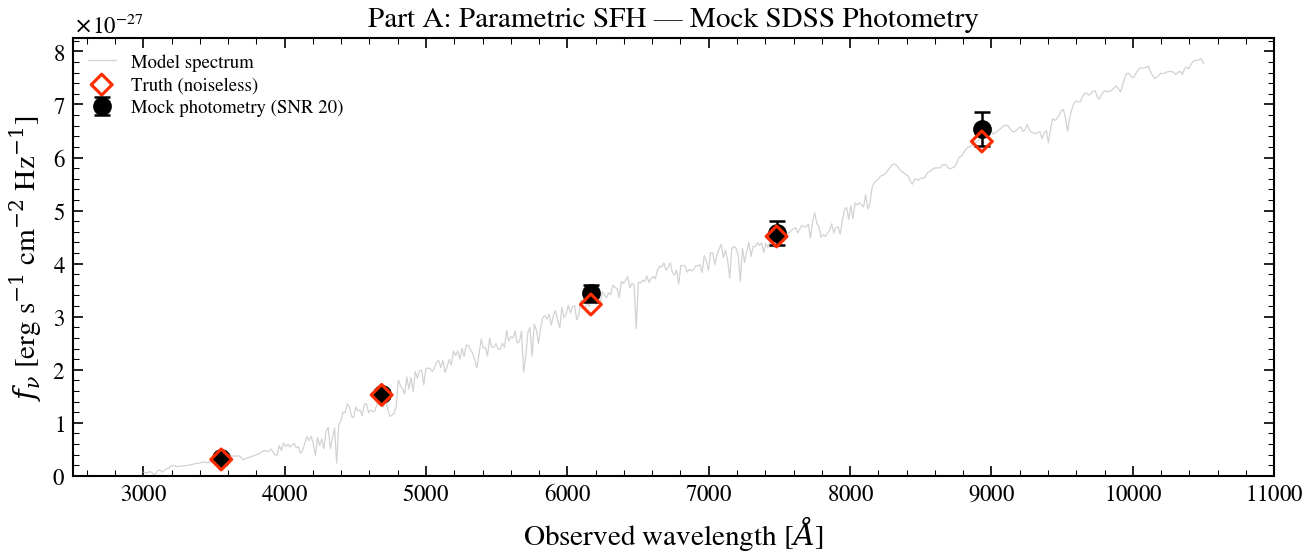

In [4]:
fig = plot_mock(model_param, mock_param, true_params_param,
                title="Part A: Parametric SFH — Mock SDSS Photometry")
plt.savefig("notebook_figures/000_A_mock_phot.png", dpi=150, bbox_inches="tight")
plt.show()

## A3. True SFH

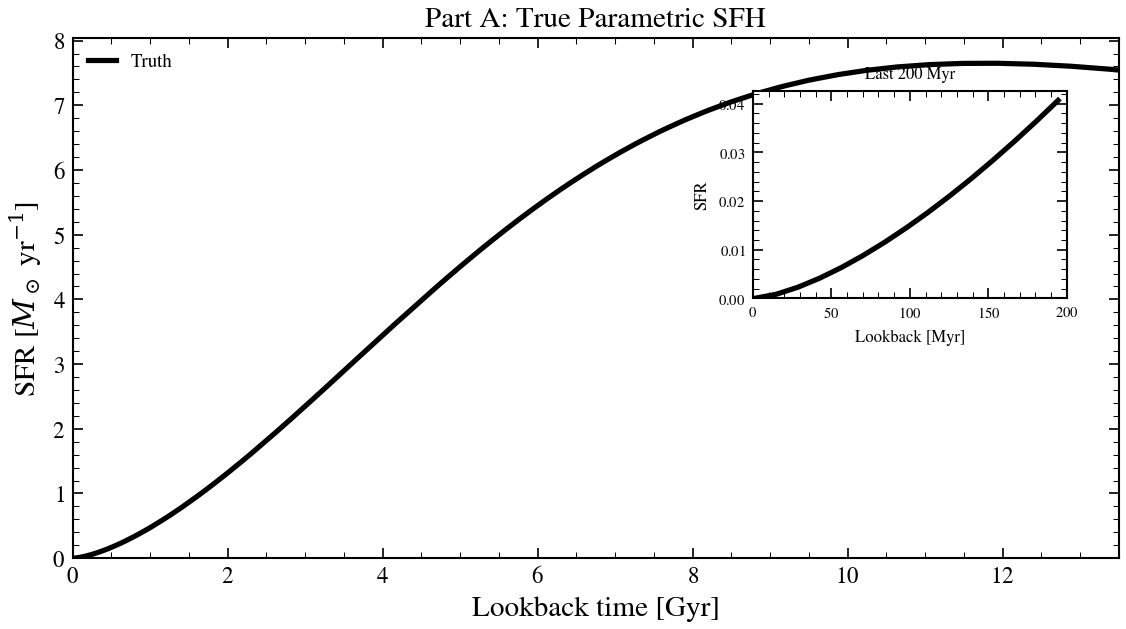

In [5]:
sfh_true_p = model_param.predict_sfh(true_params_param)
t_gyr = np.array(sfh_true_p["t_gyr"])
sfr_true_p = np.array(sfh_true_p["sfr_mean"])

fig = plot_sfh_with_inset(
    t_gyr,
    sfr_list=[(sfr_true_p,)],
    labels=["Truth"],
    colors=["k"],
    styles=[{"lw": 2.5, "zorder": 10}],
    title="Part A: True Parametric SFH",
)
plt.savefig("notebook_figures/000_A_true_sfh.png", dpi=150, bbox_inches="tight")
plt.show()

## A4. EVI Inference

In [6]:
fitter_param = Fitter(model_param, mock_param.flux_obs, mock_param.noise,
                       data_type="photometry")

key_evi_p, key = jax.random.split(key)
t0 = time.perf_counter()
result_evi_p = fitter_param.run(
    "native_geovi",
    n_iterations=50,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=10000,
    verbose=True,
    key=key_evi_p,
)
t_evi_p = time.perf_counter() - t0
print(f"\nEVI: {t_evi_p:.1f} s, "
      f"{result_evi_p.diagnostics['n_samples']} samples")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


geoVI (JIT): 7 params, 5 data points, 50 iterations, 6 samples/iter, 5 seeds


  Seed 1/5: H=1.3, 17 iters


  Seed 2/5: H=1.5, 27 iters
  Seed 3/5: H=1.5, 7 iters
  Seed 4/5: H=1.8, 7 iters


  Seed 5/5: H=1.8, 17 iters
  Drawing 10000 nonlinear posterior samples (JIT geoVI)...


<local>/Projects/diffsed/src/diffsed/fitter.py:1894: UserWarning: Seeds disagree: H = 1.6 ± 0.2 (CV=11%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_evi_jit(


  EVI (JIT) complete in 61.2s, 17/50 iterations, 10000 posterior samples

EVI: 74.7 s, 10000 samples


### A4a. EVI Photometry Fit

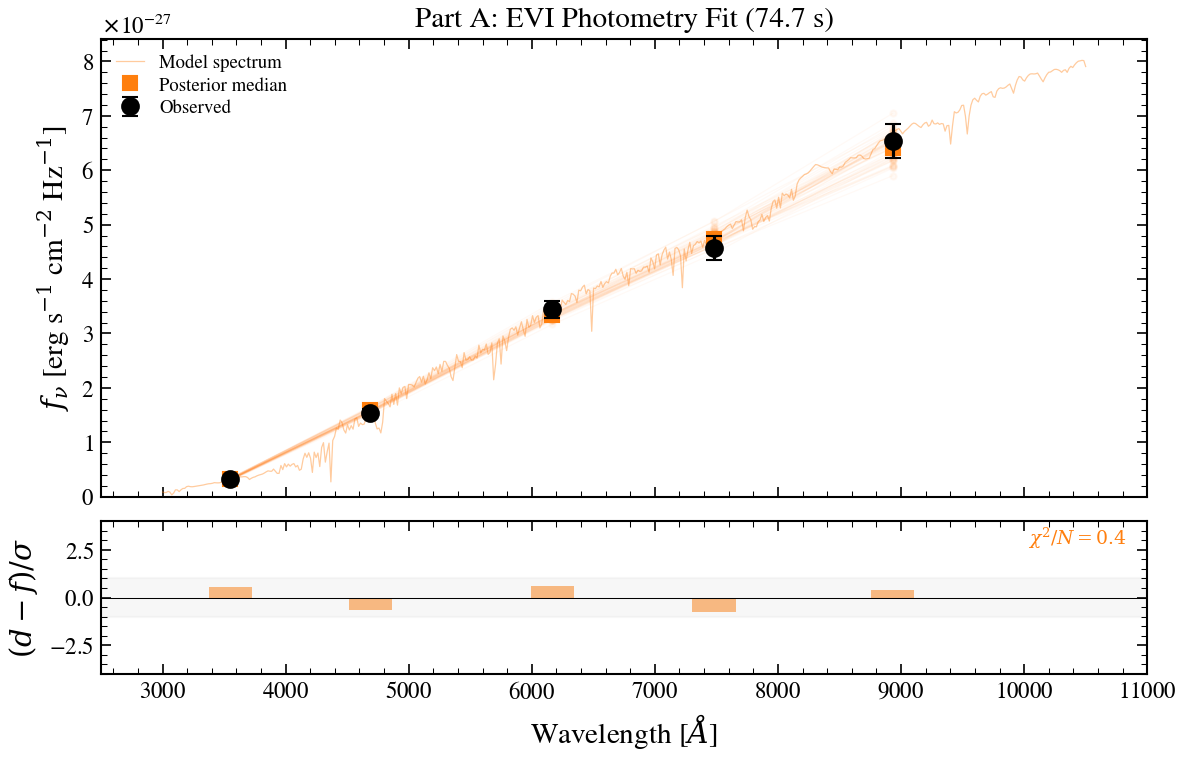

In [7]:
fig, _ = plot_phot_fit(model_param, mock_param, result_evi_p,
                       color=COLORS["geovi"],
                       title=f"Part A: EVI Photometry Fit ({t_evi_p:.1f} s)")
plt.savefig("notebook_figures/000_A_evi_phot.png", dpi=150, bbox_inches="tight")
plt.show()

### A4b. EVI SFH Recovery

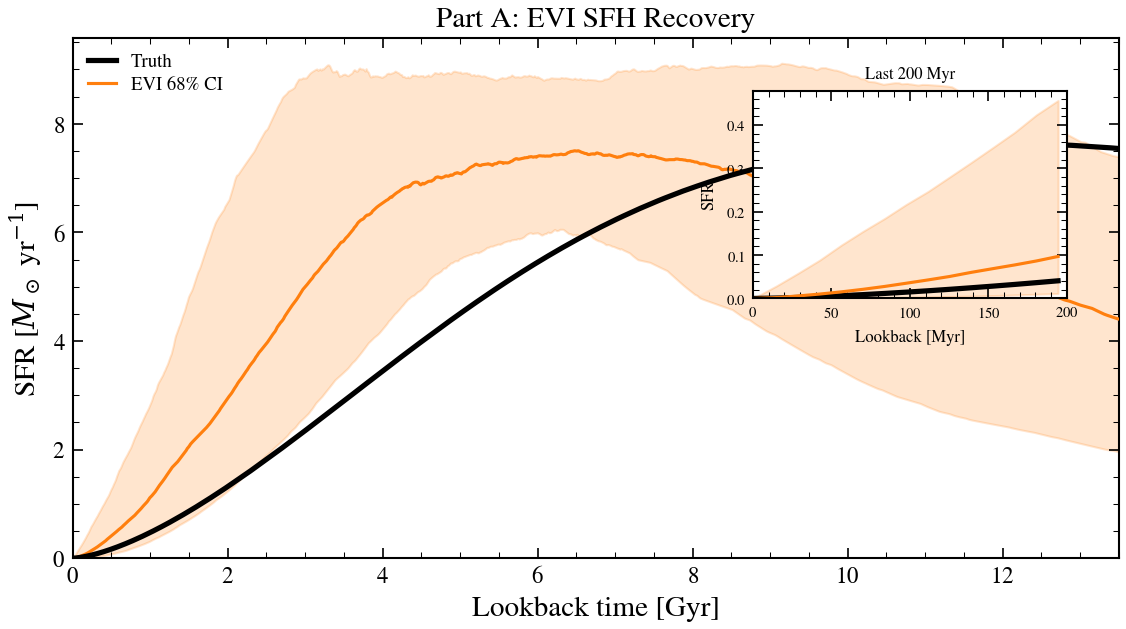

In [8]:
lo_evi_p, med_evi_p, hi_evi_p = compute_sfh_band(model_param, result_evi_p)

fig = plot_sfh_with_inset(
    t_gyr,
    sfr_list=[
        (sfr_true_p,),
        (lo_evi_p, med_evi_p, hi_evi_p),
    ],
    labels=["Truth", "EVI 68% CI"],
    colors=["k", COLORS["geovi"]],
    styles=[{"lw": 2.5, "zorder": 10}, {"zorder": 5}],
    title="Part A: EVI SFH Recovery",
)
plt.savefig("notebook_figures/000_A_evi_sfh.png", dpi=150, bbox_inches="tight")
plt.show()

### A4c. EVI Posterior

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

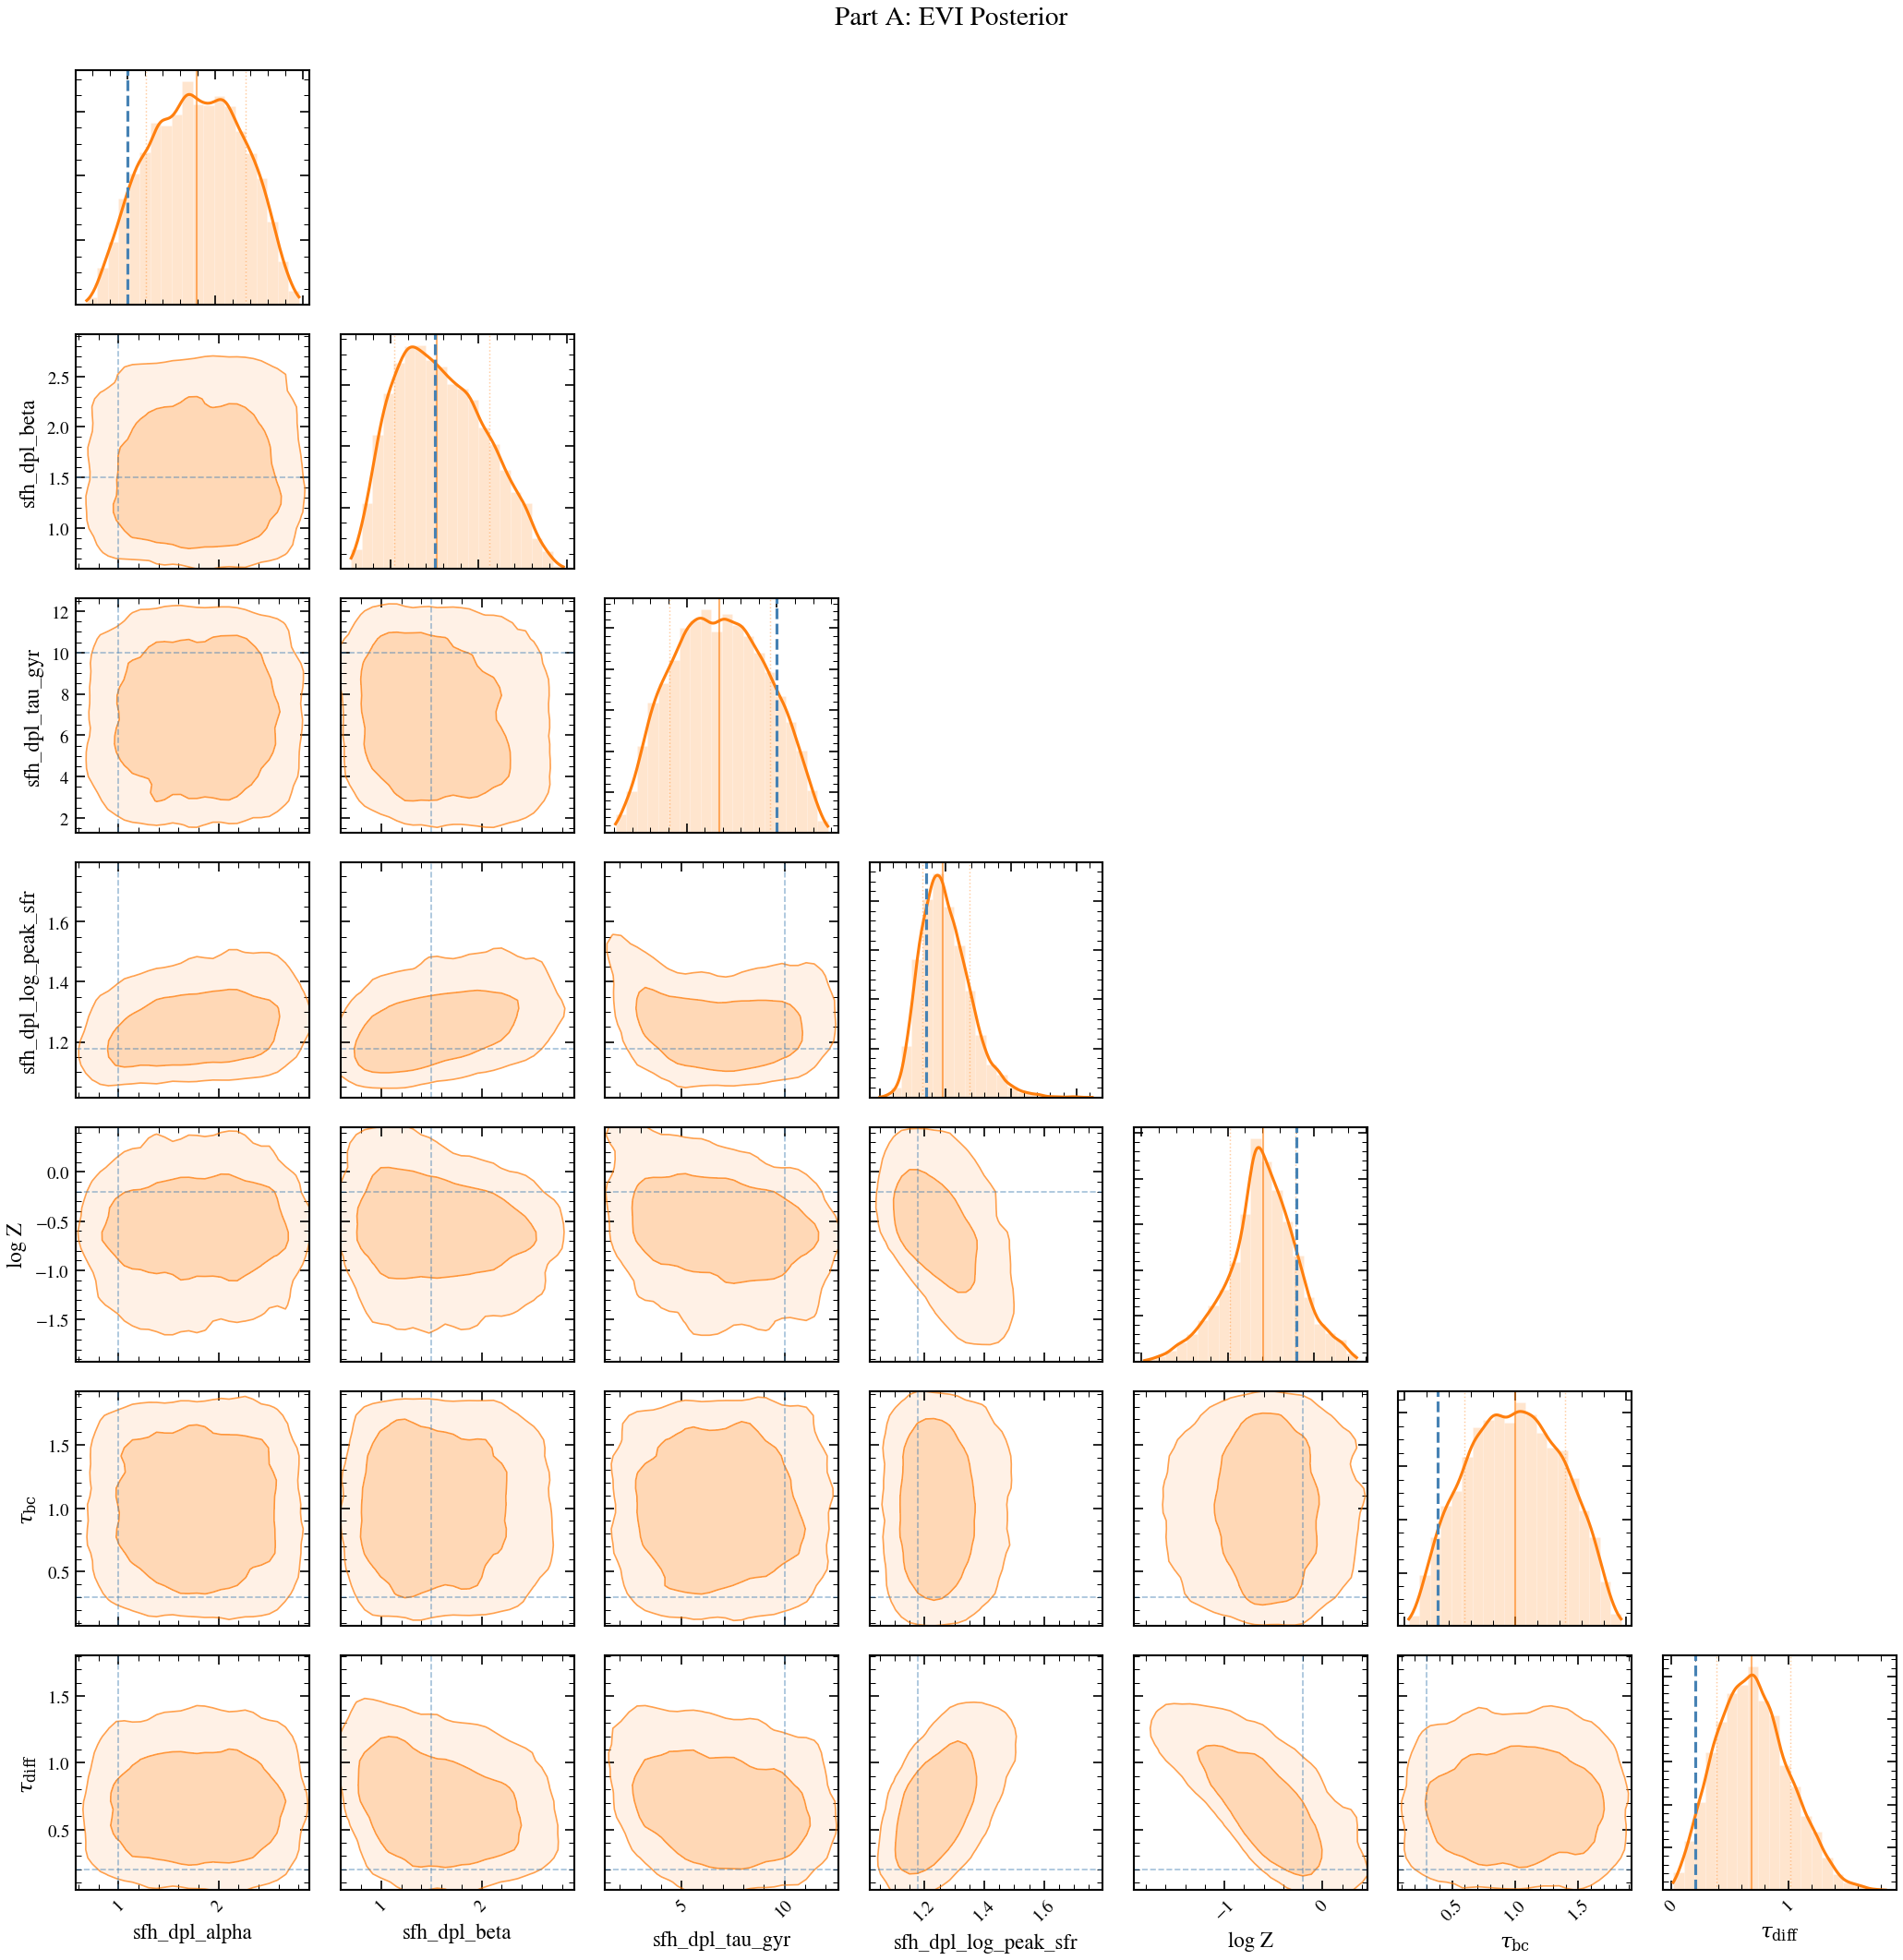

In [9]:
fig = result_evi_p.plot_corner(
    params=PHYS_PARAMS, truths=true_params_param,
    color=COLORS["geovi"], label="EVI",
)
make_truth_lines_red(fig)
fig.suptitle("Part A: EVI Posterior", y=1.02, fontsize=14)
plt.savefig("notebook_figures/000_A_evi_corner.png", dpi=150, bbox_inches="tight")
plt.show()

## A5. NUTS Cross-Validation

In [10]:
key_nuts_p, key = jax.random.split(key)

t0 = time.perf_counter()
result_map_p = fitter_param.run("map", n_steps=1000)
print(f"MAP: {time.perf_counter() - t0:.1f} s")

t0 = time.perf_counter()
result_nuts_p = fitter_param.run(
    "nuts",
    init_from=result_map_p,
    n_warmup=2000,
    n_burnin=500,
    n_samples=5000,
    target_accept_rate=0.8,
    key=key_nuts_p,
)
t_nuts_p = time.perf_counter() - t0
n_div = result_nuts_p.diagnostics.get("n_divergent", 0)
n_samp = result_nuts_p.diagnostics.get("n_samples", 0)
print(f"NUTS: {t_nuts_p:.1f} s, {n_samp} samples, {n_div} divergences")

# geoVI+NUTS hybrid: geoVI optimization for fast init, NUTS for exact posteriors
t0 = time.perf_counter()
result_geovi_nuts_p = fitter_param.run(
    "geovi_nuts",
    n_iterations=10,
    n_samples=3,
    n_posterior_samples=2000,
    key=key_nuts_p,
)
t_gn = time.perf_counter() - t0
print(f"geoVI+NUTS: {t_gn:.1f} s")

  Step     0/1000: loss = 633.4704
  Step   200/1000: loss = 1.1601
  Step   400/1000: loss = 1.0712
  Step   600/1000: loss = 0.9953
  Step   800/1000: loss = 0.9197
  Step   999/1000: loss = 0.8590
  MAP (ADAM) complete in 0.2s, 1000 steps
MAP: 0.3 s


NUTS: 7 parameters, 2000 warmup, 500 burn-in, 5000 samples, target_accept=0.8


  Warmup complete (1.1s). Step size: 0.0011


  Burn-in complete (500 steps discarded)


  Sample 200/5000


...

MCG: Iteration 6 ⛰:-3.9113e-05 Δ⛰:1.2072e-07 ➽:5.9931e-03 |∇|:6.9133e-04 ➽:3.5719e-01


M: →:1.0 ↺:False #∇²:12 |↘|:3.576160e-03 🞋:7.000000e-05
M: Iteration 2 ⛰:+5.044855e+00 Δ⛰:3.861987e-05 🞋:1.000000e-03


  Drawing 2000 posterior samples via BlackJAX NUTS...


  Warmup done (200 steps). Sampling...


  geovi complete in 24.0s, 10 iterations, 2006 posterior samples
geoVI+NUTS: 25.0 s


### A5a. Convergence Diagnostics

In [11]:
convergence_table({
    "native_geovi": result_evi_p,
    "geoVI+NUTS": result_geovi_nuts_p,
    "NUTS": result_nuts_p,
})

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
native_geovi        7312    10000        —        —         OK
geoVI+NUTS           872     2006        —        —         OK
NUTS                 507     5000        —       97       WARN

Warnings:
  [NUTS] WARNING: 97/5000 divergent transitions (1.9%) — posterior may be unreliable


{'native_geovi': {'ess_min': np.float64(7311.675937297098),
  'ess_median': 10000.0,
  'n_params_low_ess': 0,
  'converged': True,
  'warnings': []},
 'geoVI+NUTS': {'ess_min': np.float64(872.245545556853),
  'ess_median': 2006.0,
  'n_params_low_ess': 0,
  'converged': True,
  'warnings': []},
 'NUTS': {'ess_min': np.float64(507.1779038861175),
  'ess_median': 5000.0,
  'n_params_low_ess': 0,
  'n_divergent': 97,
  'divergence_pct': 1.94,
  'converged': False,
  'warnings': ['WARNING: 97/5000 divergent transitions (1.9%) — posterior may be unreliable']}}

### A5b. NUTS Photometry Fit

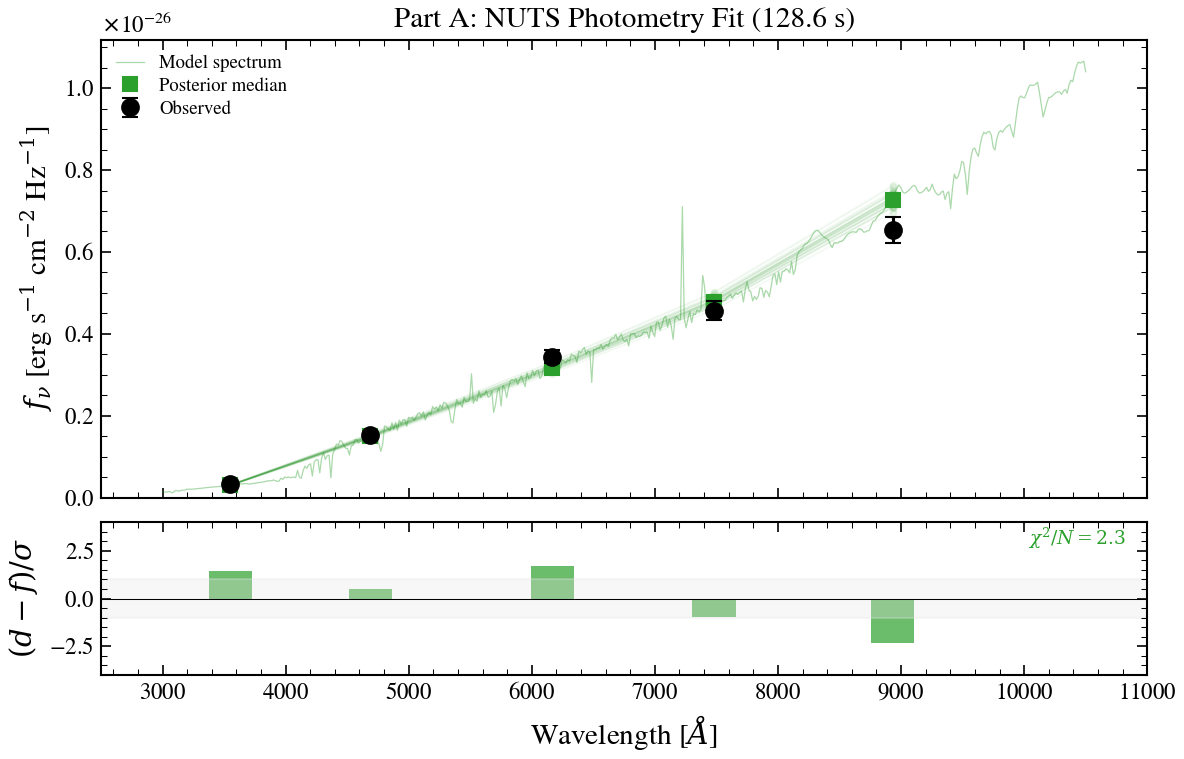

In [12]:
fig, _ = plot_phot_fit(model_param, mock_param, result_nuts_p,
                       color=COLORS["nuts"],
                       title=f"Part A: NUTS Photometry Fit ({t_nuts_p:.1f} s)")
plt.savefig("notebook_figures/000_A_nuts_phot.png", dpi=150, bbox_inches="tight")
plt.show()

### A5c. Combined SFH: Truth + EVI + NUTS

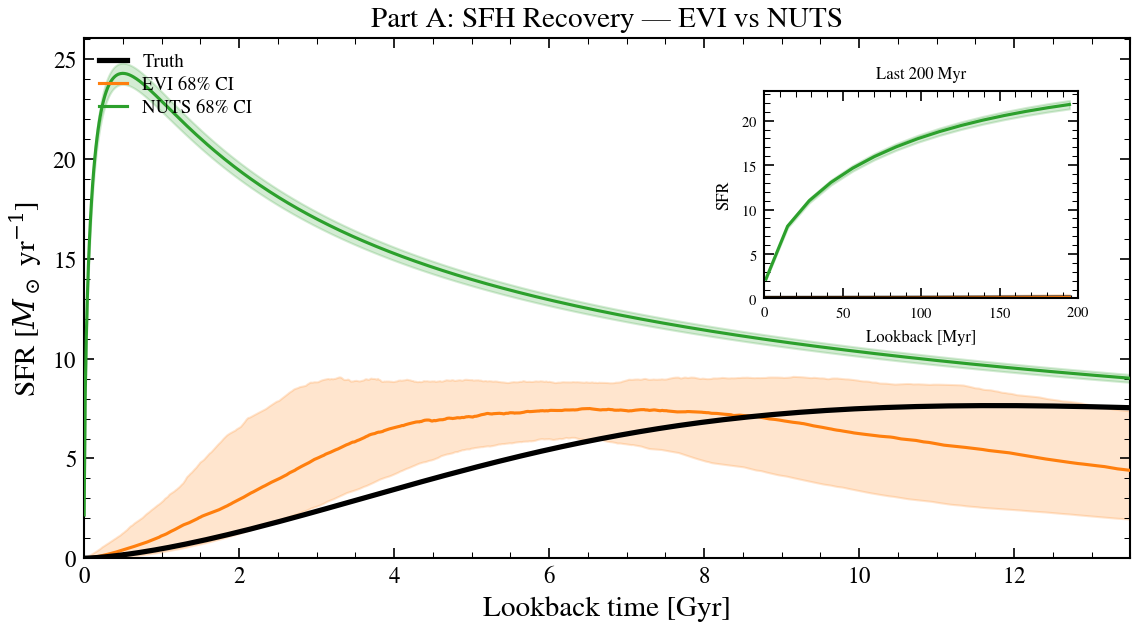

In [13]:
lo_nuts_p, med_nuts_p, hi_nuts_p = compute_sfh_band(model_param, result_nuts_p)

fig = plot_sfh_with_inset(
    t_gyr,
    sfr_list=[
        (sfr_true_p,),
        (lo_evi_p, med_evi_p, hi_evi_p),
        (lo_nuts_p, med_nuts_p, hi_nuts_p),
    ],
    labels=["Truth", "EVI 68% CI", "NUTS 68% CI"],
    colors=["k", COLORS["geovi"], COLORS["nuts"]],
    styles=[{"lw": 2.5, "zorder": 10}, {"zorder": 5}, {"zorder": 4}],
    title="Part A: SFH Recovery — EVI vs NUTS",
)
plt.savefig("notebook_figures/000_A_combined_sfh.png", dpi=150, bbox_inches="tight")
plt.show()

### A5d. Combined Posterior: EVI + NUTS Overlaid

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

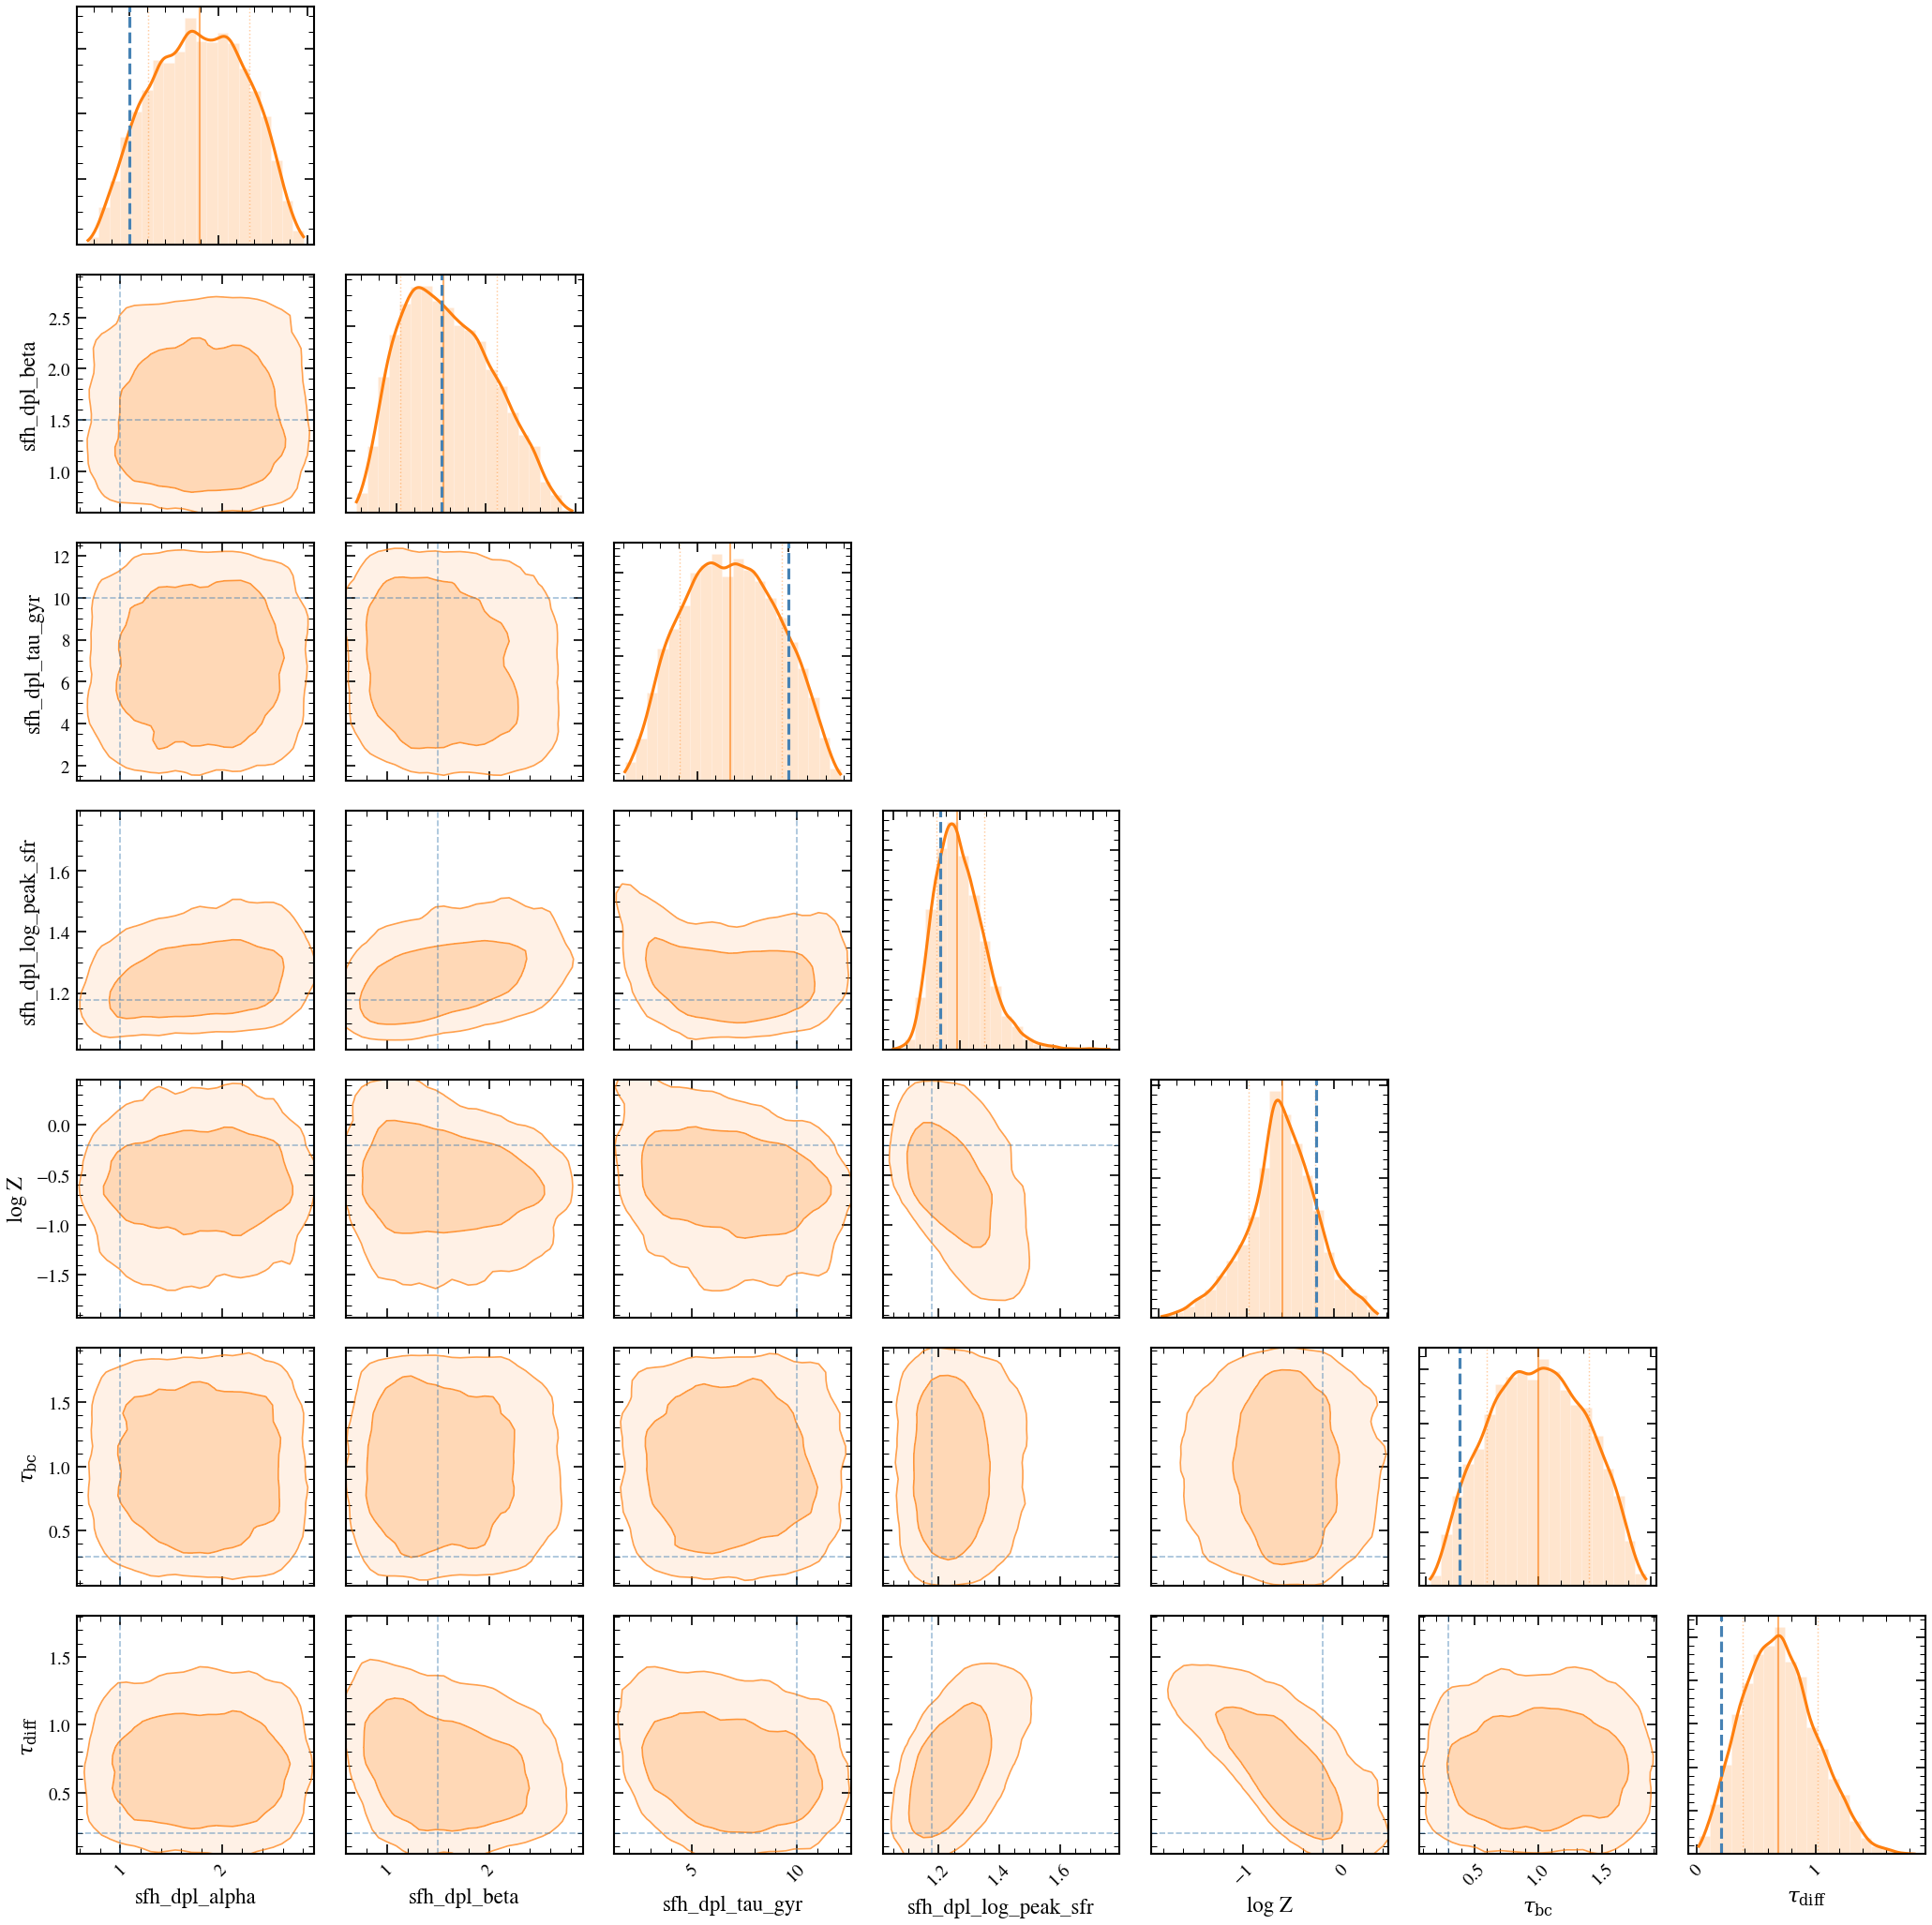

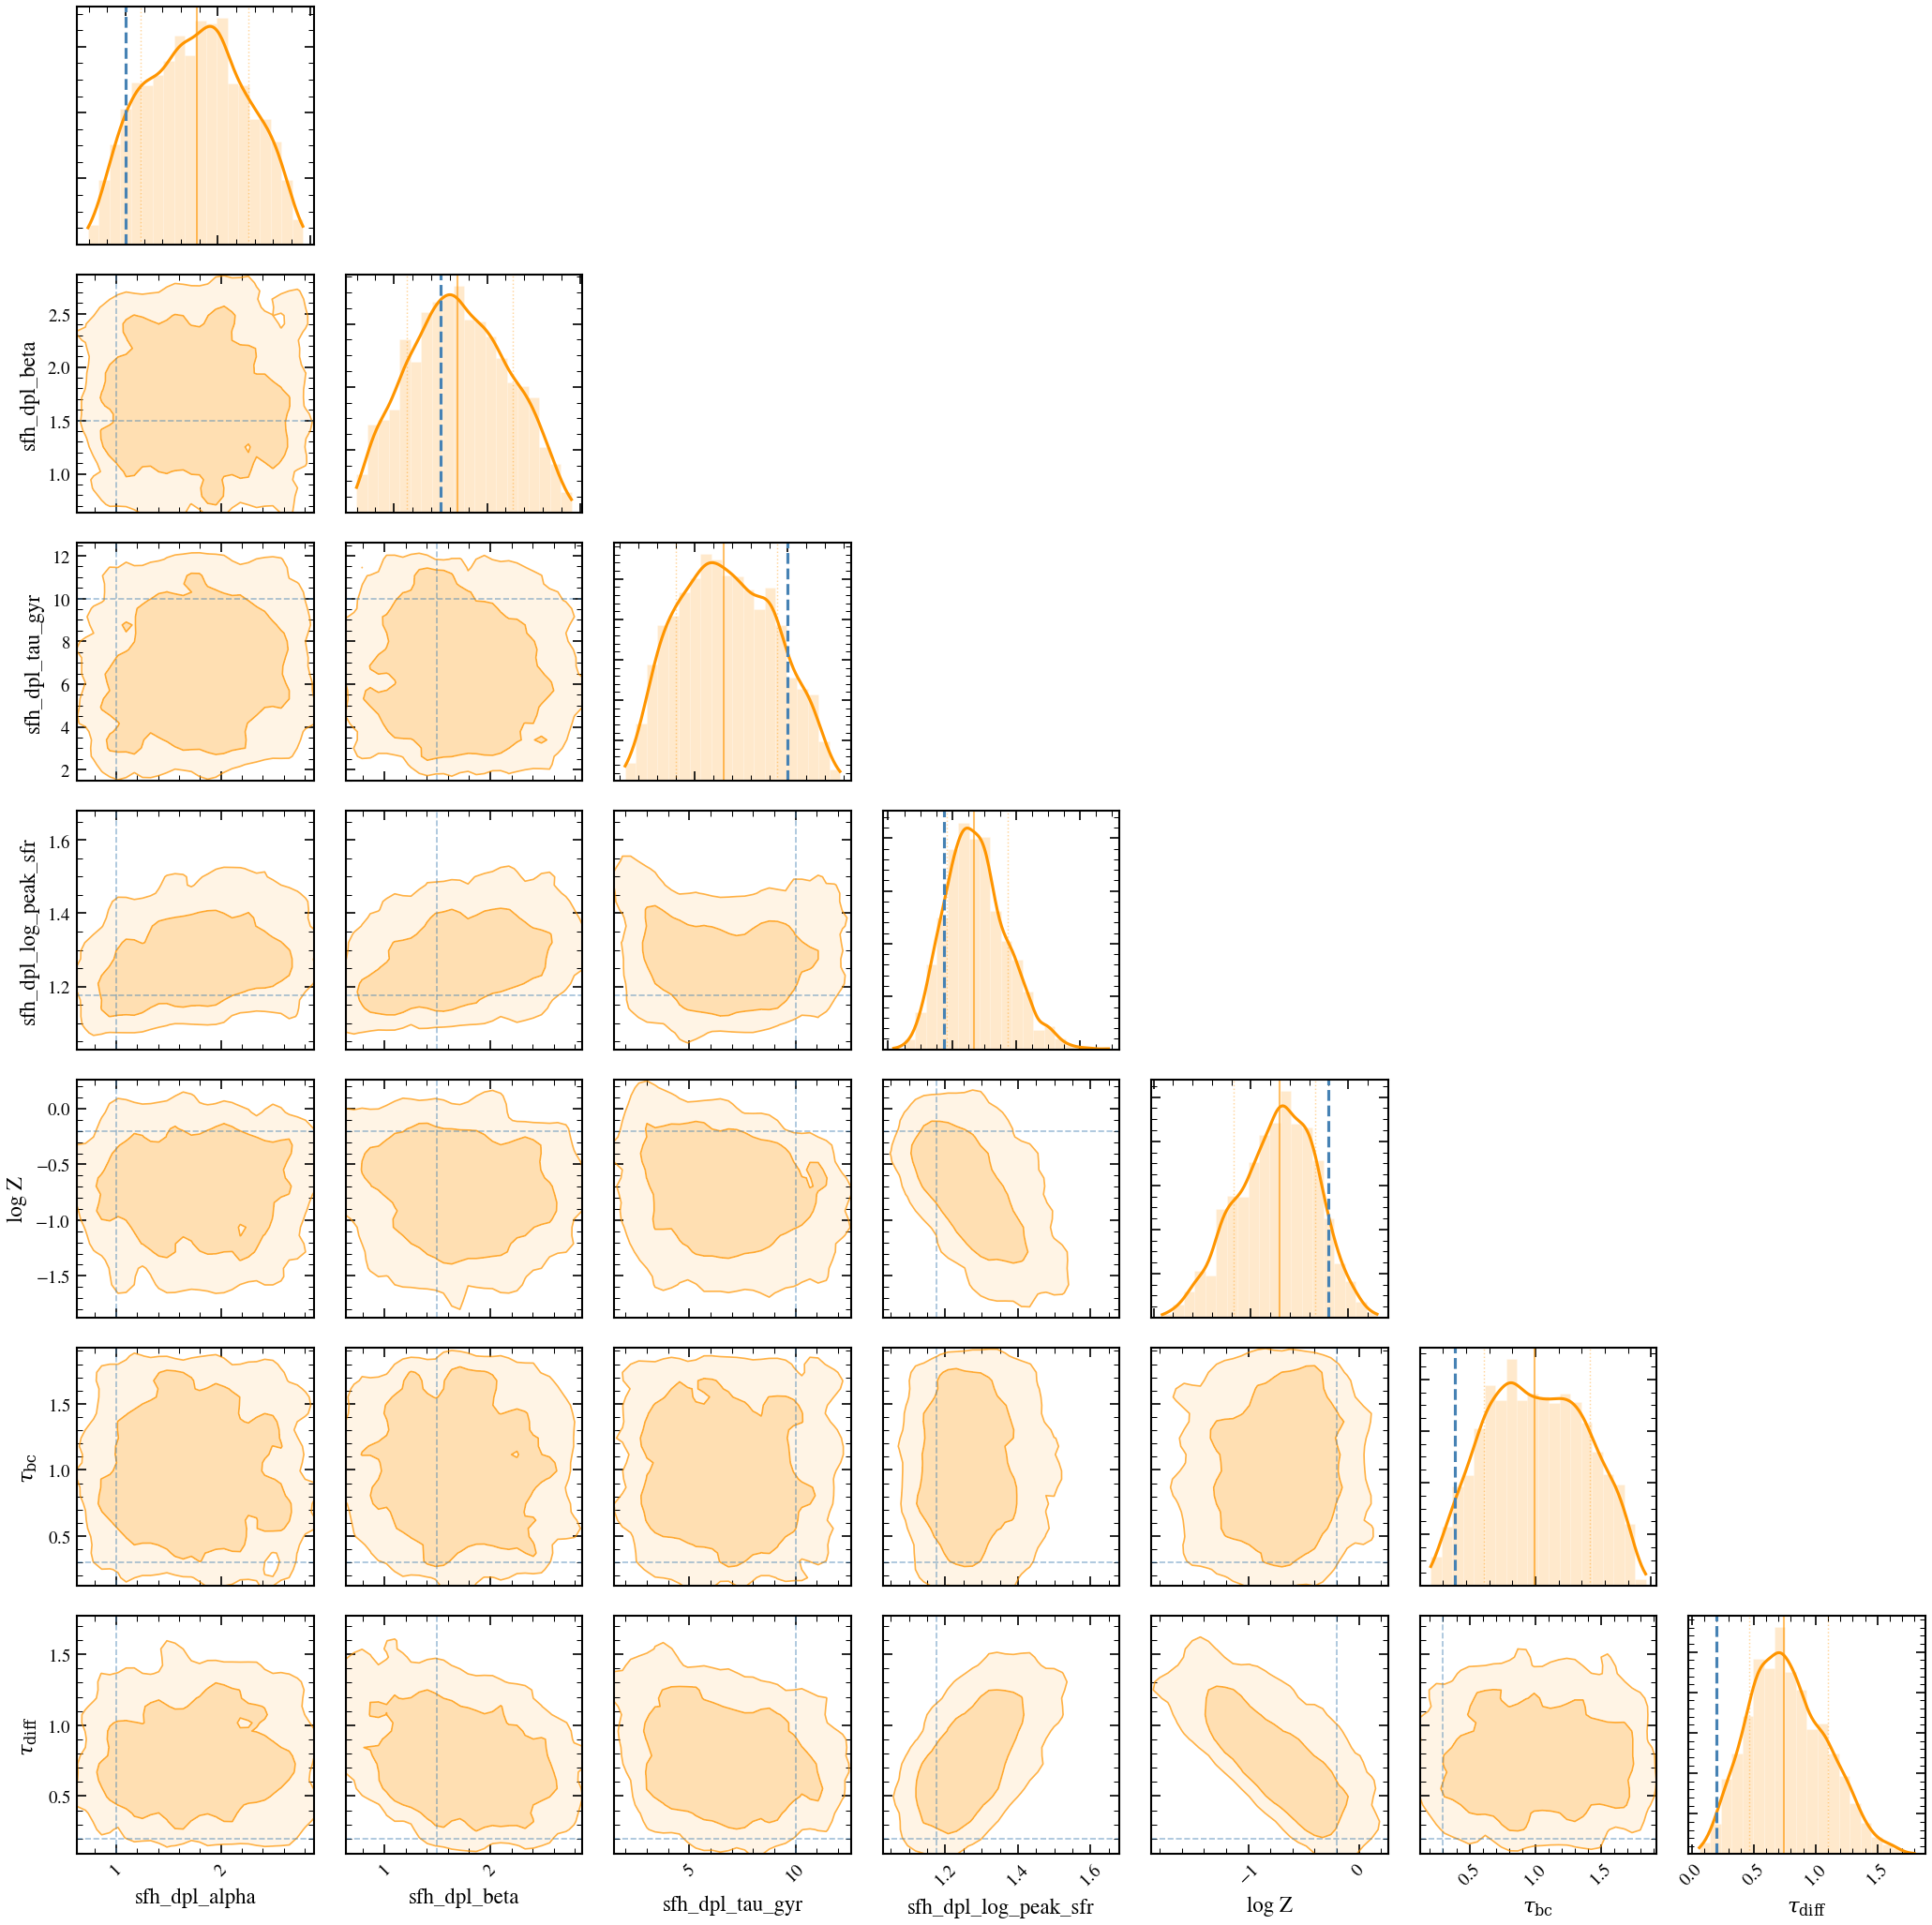

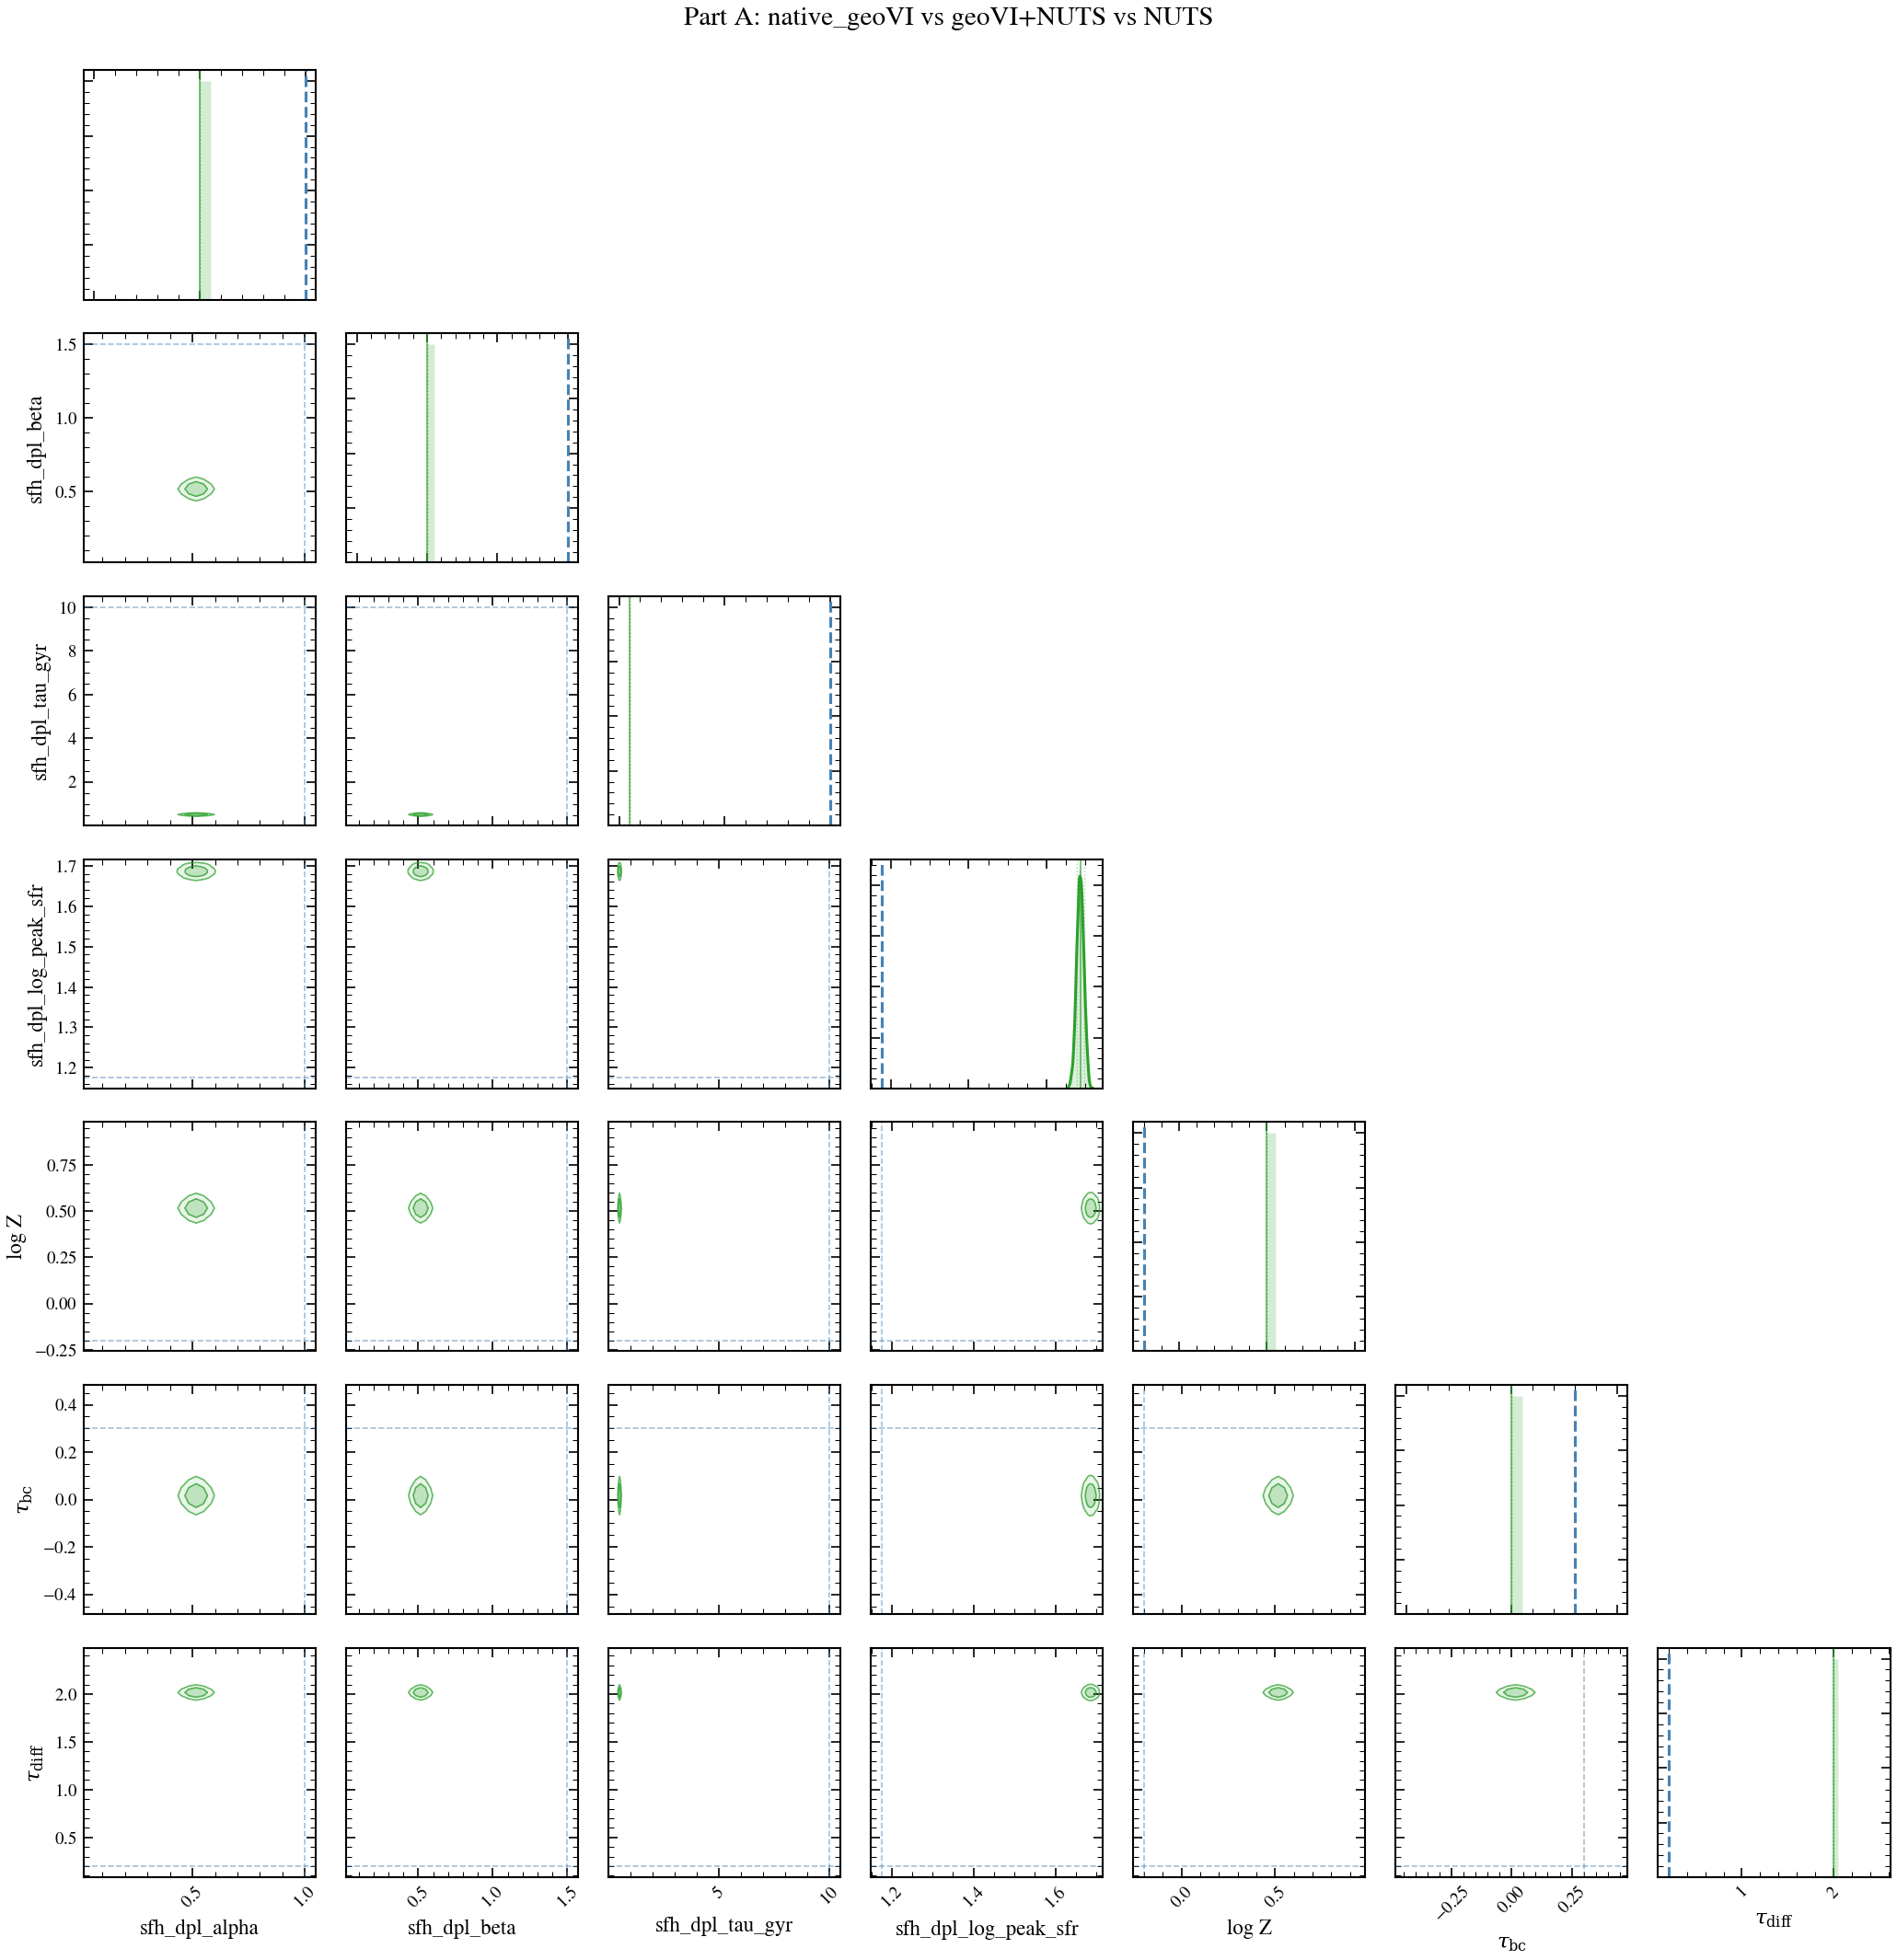

In [14]:
fig = plot_corner_comparison(
    [result_evi_p, result_geovi_nuts_p, result_nuts_p],
    ["native_geoVI", "geoVI+NUTS", "NUTS"],
    colors=[COLORS["geovi"], COLORS.get("evi", "C2"), COLORS["nuts"]],
    truths=true_params_param,
    params=PHYS_PARAMS,
)
make_truth_lines_red(fig)
if fig is not None:
    fig.suptitle("Part A: native_geoVI vs geoVI+NUTS vs NUTS", y=1.02, fontsize=14)
    plt.savefig("notebook_figures/000_A_combined_corner.png",
                dpi=150, bbox_inches="tight")
    plt.show()

---
# Part B: Stochastic SFH ($D \approx 137$)

Now we add the GP correlated field with PSD-governed burstiness.
The latent vector $\boldsymbol{\xi} \in \mathbb{R}^{128}$ encodes
the stochastic fluctuations, giving $D = 128 + 9 = 137$.

## B1. Model and Mock

In [15]:
spec_stoch = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["dpl", "field"],
    n_grid=128,
)
model_stoch = Model(spec_stoch, ssp_data, filters=filters)

key_s = jax.random.PRNGKey(42)
true_params_stoch = spec_stoch.sample(key_s)
true_params_stoch.update(
    sfh_dpl_alpha=1.0,
    sfh_dpl_beta=1.5,
    sfh_dpl_tau_gyr=8.0,
    sfh_dpl_log_peak_sfr=1.477,
    sfh_field_psd_sigma=2.0,
    sfh_field_psd_tau_myr=20.0,
    met_logzsol=-0.3,
    dust_tau_bc=0.5,
    dust_tau_diff=0.3,
)
mock_stoch = model_stoch.mock(true_params_stoch, snr=20.0, key=key_s)
print(f"Stochastic model: D = {spec_stoch.n_free} scalar + 128 GP = "
      f"{spec_stoch.n_free + 128}, {len(mock_stoch.flux_obs)} bands")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_48918/1168914442.py:16: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch = Model(spec_stoch, ssp_data, filters=filters)


Stochastic model: D = 9 scalar + 128 GP = 137, 5 bands


## B2. Mock Photometry + Spectrum

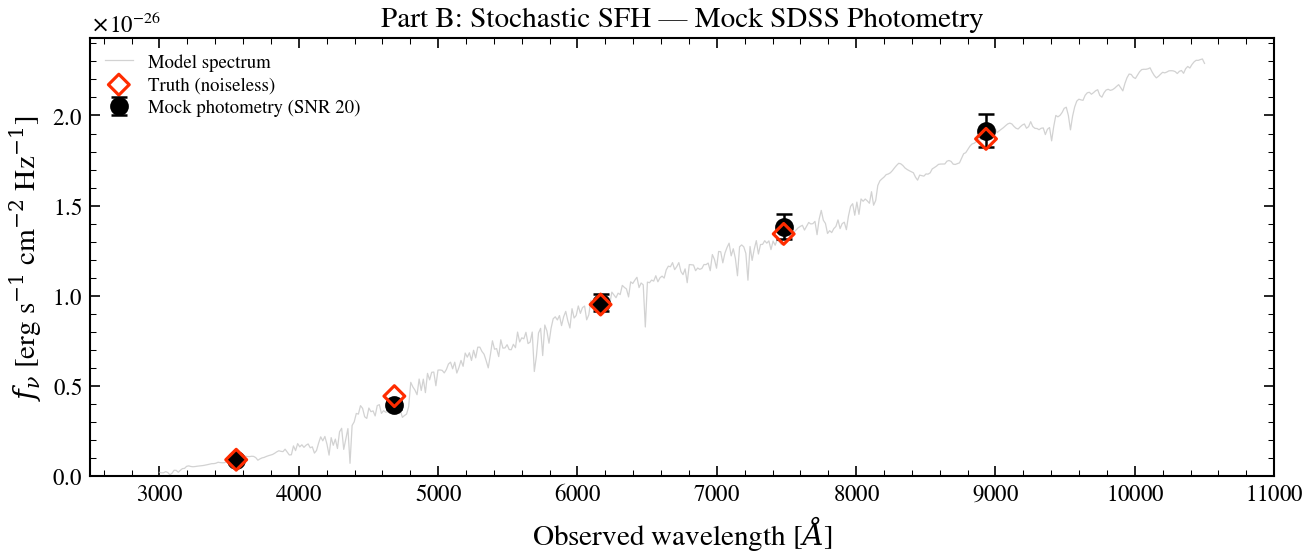

In [16]:
fig = plot_mock(model_stoch, mock_stoch, true_params_stoch,
                title="Part B: Stochastic SFH — Mock SDSS Photometry")
plt.savefig("notebook_figures/000_B_mock_phot.png", dpi=150, bbox_inches="tight")
plt.show()

## B3. True SFH

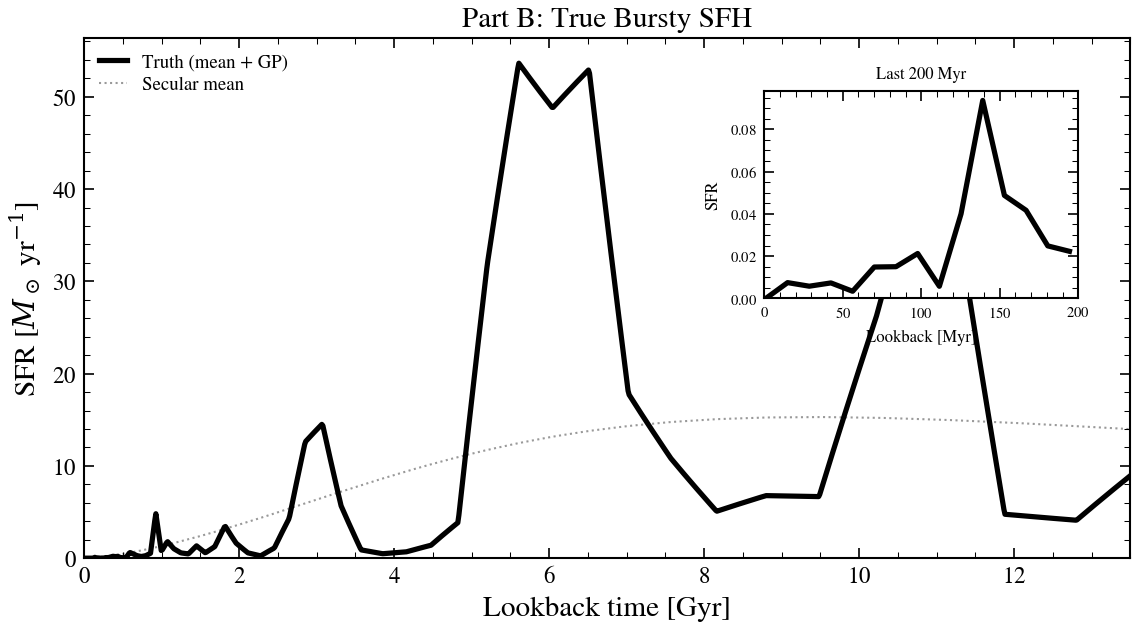

In [17]:
sfh_true_s = model_stoch.predict_sfh(true_params_stoch)
t_gyr_s = np.array(sfh_true_s["t_gyr"])
sfr_true_s = np.array(sfh_true_s["sfr_full"])
sfr_mean_s = np.array(sfh_true_s["sfr_mean"])

fig = plot_sfh_with_inset(
    t_gyr_s,
    sfr_list=[(sfr_true_s,)],
    labels=["Truth (mean + GP)"],
    colors=["k"],
    styles=[{"lw": 2.5, "zorder": 10}],
    title="Part B: True Bursty SFH",
    sfr_mean=sfr_mean_s,
)
plt.savefig("notebook_figures/000_B_true_sfh.png", dpi=150, bbox_inches="tight")
plt.show()

## B4. EVI Inference

In [18]:
fitter_stoch = Fitter(model_stoch, mock_stoch.flux_obs, mock_stoch.noise,
                       data_type="photometry")

key_evi_s, key = jax.random.split(key)
t0 = time.perf_counter()
result_evi_s = fitter_stoch.run(
    "native_geovi",
    n_iterations=50,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=10000,
    verbose=True,
    key=key_evi_s,
)
t_evi_s = time.perf_counter() - t0
print(f"\nEVI: {t_evi_s:.1f} s, "
      f"{result_evi_s.diagnostics['n_samples']} samples")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


geoVI (JIT): 137 params, 5 data points, 50 iterations, 6 samples/iter, 5 seeds


  Seed 1/5: H=5.6, 7 iters


  Seed 2/5: H=8.8, 12 iters
  Seed 3/5: H=4.8, 7 iters


  Seed 4/5: H=3.9, 12 iters
  Seed 5/5: H=4.4, 7 iters
  Drawing 10000 nonlinear posterior samples (JIT geoVI)...


<local>/Projects/diffsed/src/diffsed/fitter.py:1894: UserWarning: Seeds disagree: H = 5.5 ± 1.8 (CV=32%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_evi_jit(


  EVI (JIT) complete in 79.5s, 12/50 iterations, 10000 posterior samples

EVI: 96.0 s, 10000 samples


### B4a. EVI Photometry Fit

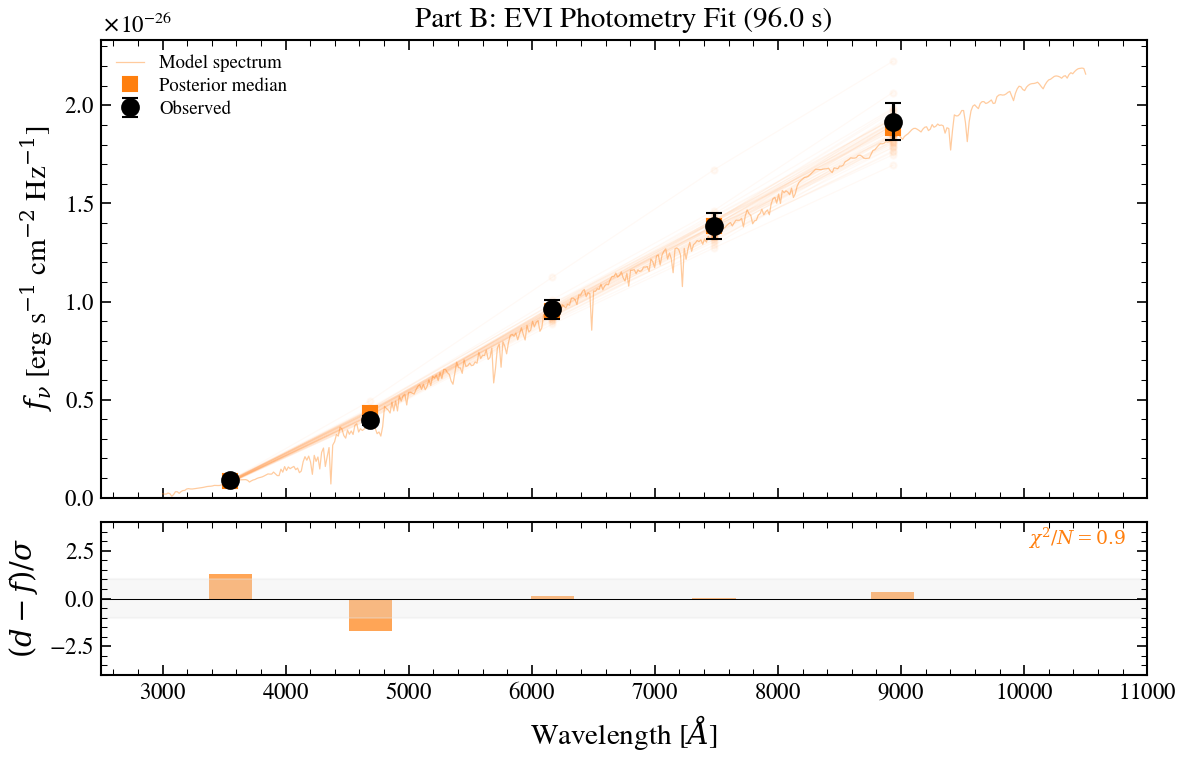

In [19]:
fig, _ = plot_phot_fit(model_stoch, mock_stoch, result_evi_s,
                       color=COLORS["geovi"],
                       title=f"Part B: EVI Photometry Fit ({t_evi_s:.1f} s)")
plt.savefig("notebook_figures/000_B_evi_phot.png", dpi=150, bbox_inches="tight")
plt.show()

### B4b. EVI SFH Recovery

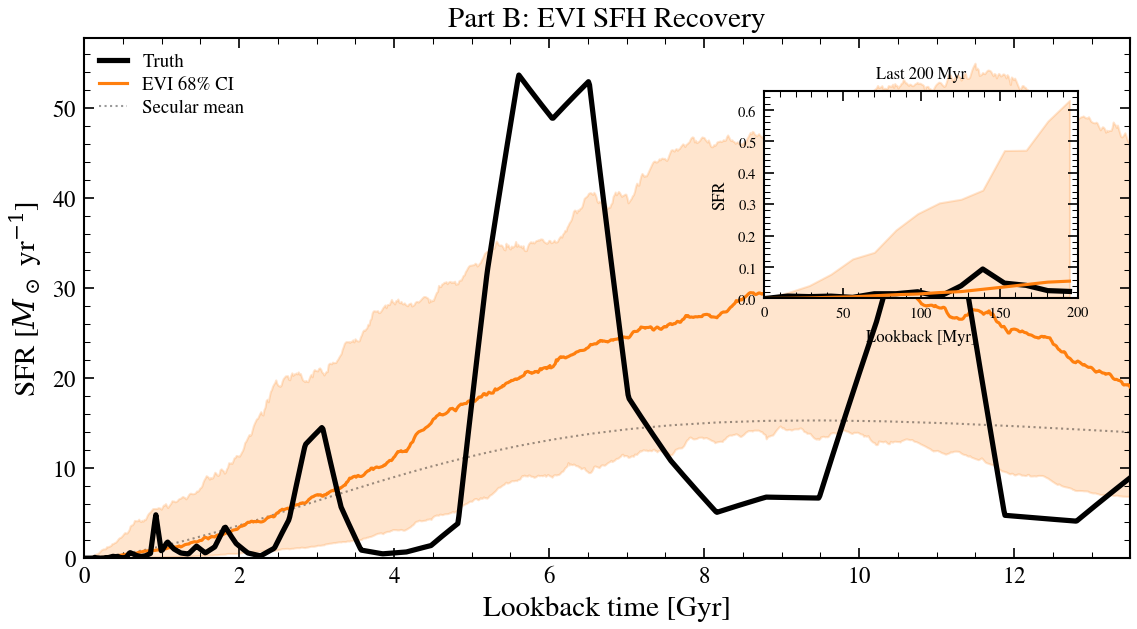

In [20]:
lo_evi_s, med_evi_s, hi_evi_s = compute_sfh_band(model_stoch, result_evi_s)

fig = plot_sfh_with_inset(
    t_gyr_s,
    sfr_list=[
        (sfr_true_s,),
        (lo_evi_s, med_evi_s, hi_evi_s),
    ],
    labels=["Truth", "EVI 68% CI"],
    colors=["k", COLORS["geovi"]],
    styles=[{"lw": 2.5, "zorder": 10}, {"zorder": 5}],
    title="Part B: EVI SFH Recovery",
    sfr_mean=sfr_mean_s,
)
plt.savefig("notebook_figures/000_B_evi_sfh.png", dpi=150, bbox_inches="tight")
plt.show()

### B4c. EVI Posterior

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

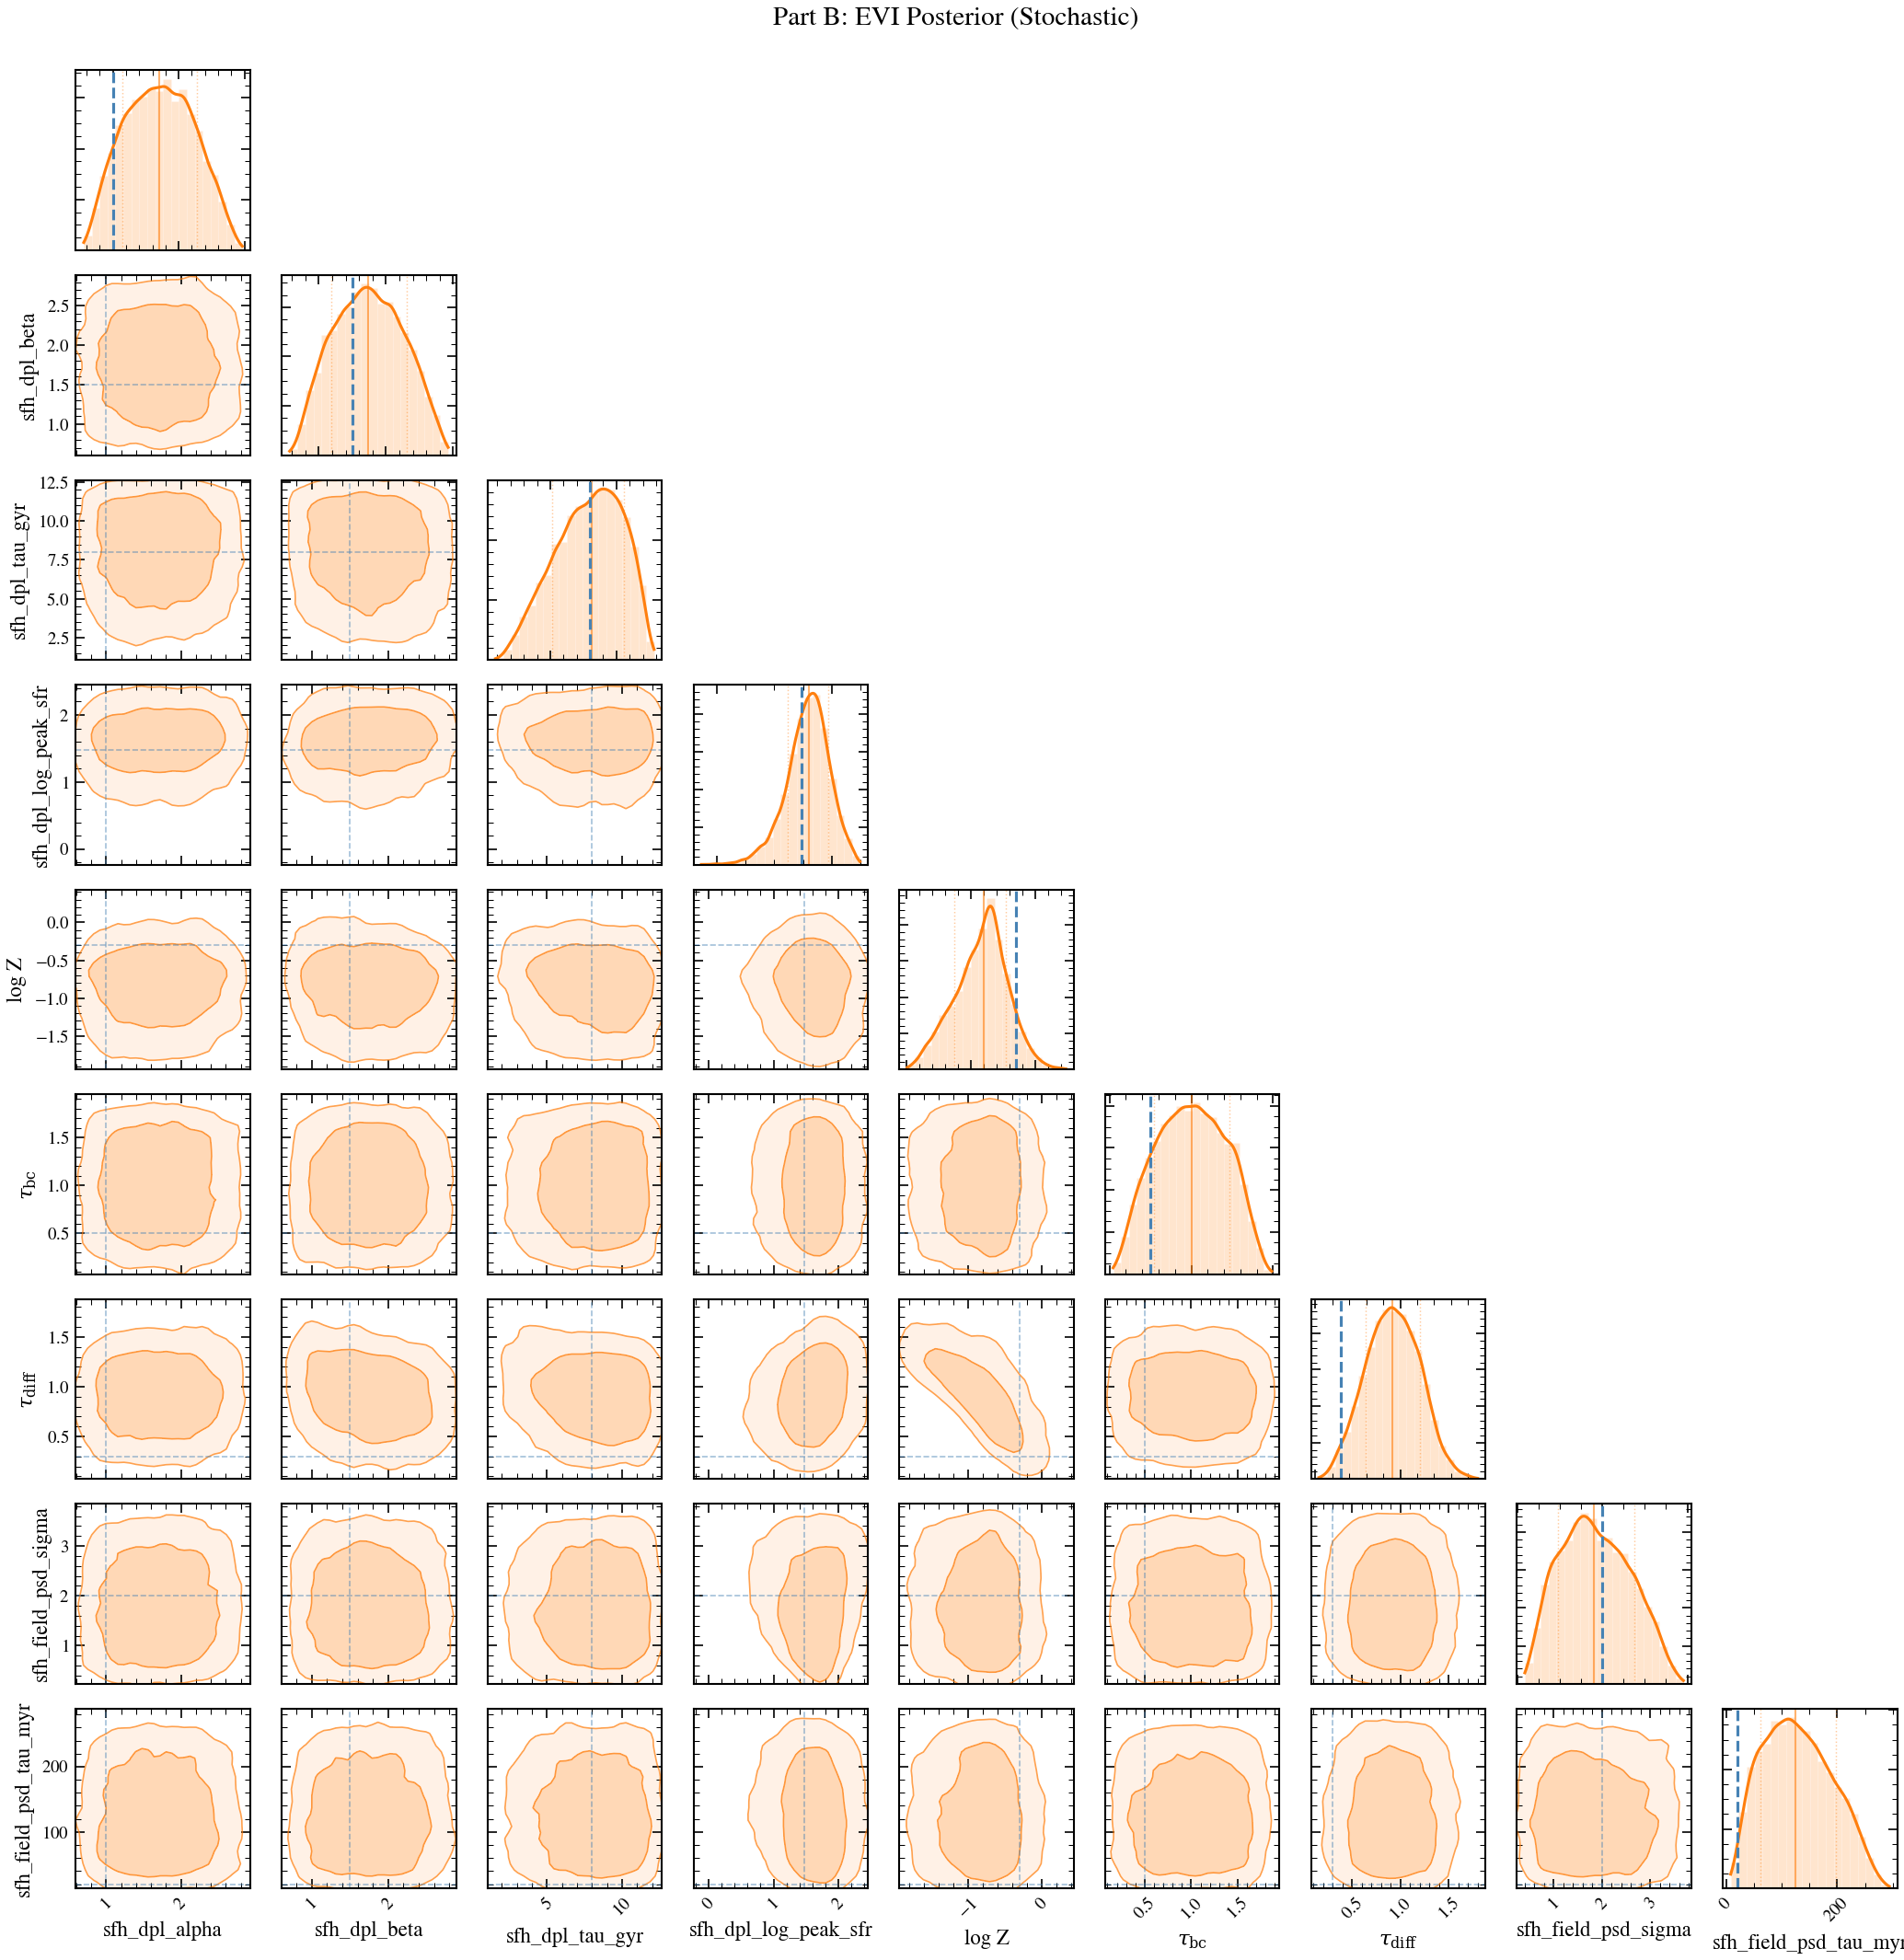

In [21]:
fig = result_evi_s.plot_corner(
    params=PHYS_PARAMS_STOCH, truths=true_params_stoch,
    color=COLORS["geovi"], label="EVI",
)
make_truth_lines_red(fig)
fig.suptitle("Part B: EVI Posterior (Stochastic)", y=1.02, fontsize=14)
plt.savefig("notebook_figures/000_B_evi_corner.png", dpi=150, bbox_inches="tight")
plt.show()

## B5. NUTS Cross-Validation

NUTS at $D \sim 137$ is expensive and may show divergences.
We run it as a cross-check — not as the production method.

In [22]:
key_nuts_s, key = jax.random.split(key)

t0 = time.perf_counter()
result_map_s = fitter_stoch.run("map", n_steps=1000)
print(f"MAP: {time.perf_counter() - t0:.1f} s")

t0 = time.perf_counter()
result_nuts_s = fitter_stoch.run(
    "nuts",
    init_from=result_map_s,
    n_warmup=2000,
    n_burnin=500,
    n_samples=3000,
    target_accept_rate=0.8,
    key=key_nuts_s,
)
t_nuts_s = time.perf_counter() - t0
n_div_s = result_nuts_s.diagnostics.get("n_divergent", 0)
n_samp_s = result_nuts_s.diagnostics.get("n_samples", 0)
print(f"NUTS: {t_nuts_s:.1f} s, {n_samp_s} samples, {n_div_s} divergences")

  Step     0/1000: loss = 909.4199
  Step   200/1000: loss = 5.8446
  Step   400/1000: loss = 4.7986
  Step   600/1000: loss = 4.2347
  Step   800/1000: loss = 3.8225
  Step   999/1000: loss = 3.4947
  MAP (ADAM) complete in 0.3s, 1000 steps
MAP: 0.3 s
NUTS: 137 parameters, 2000 warmup, 500 burn-in, 3000 samples, target_accept=0.8


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_48918/1925424180.py:8: UserWarning: Stochastic SFH with NUTS: sampling 137 dimensions (128 psd_xi + 9 physical). This is computationally expensive. Recommended: method='geovi' (10-100x faster).
  result_nuts_s = fitter_stoch.run(


  Warmup complete (1.4s). Step size: 0.0130


  Burn-in complete (500 steps discarded)


  Sample 200/3000


...

  Sample 2400/3000


  Sample 2600/3000


  Sample 2800/3000


  Sample 3000/3000


  NUTS complete in 37.1s. Divergences: 88/3000
NUTS: 39.6 s, 3000 samples, 88 divergences


### B5a. Convergence Diagnostics

In [23]:
convergence_table({"EVI": result_evi_s, "NUTS": result_nuts_s})

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
EVI                 9131    10000        —        —         OK
NUTS                   3     3000        —       88       WARN

Warnings:
  [NUTS] Low ESS: 1/18 params below 100 (min ESS = 3 for sfh_field_psd_tau_myr)
  [NUTS] WARNING: 88/3000 divergent transitions (2.9%) — posterior may be unreliable


{'EVI': {'ess_min': np.float64(9130.85845888754),
  'ess_median': 10000.0,
  'n_params_low_ess': 0,
  'converged': True,
  'warnings': []},
 'NUTS': {'ess_min': np.float64(3.385485483333871),
  'ess_median': 3000.0,
  'n_params_low_ess': 1,
  'n_divergent': 88,
  'divergence_pct': 2.933333333333333,
  'converged': False,
  'warnings': ['Low ESS: 1/18 params below 100 (min ESS = 3 for sfh_field_psd_tau_myr)',
   'WARNING: 88/3000 divergent transitions (2.9%) — posterior may be unreliable']}}

### B5b. NUTS Photometry Fit

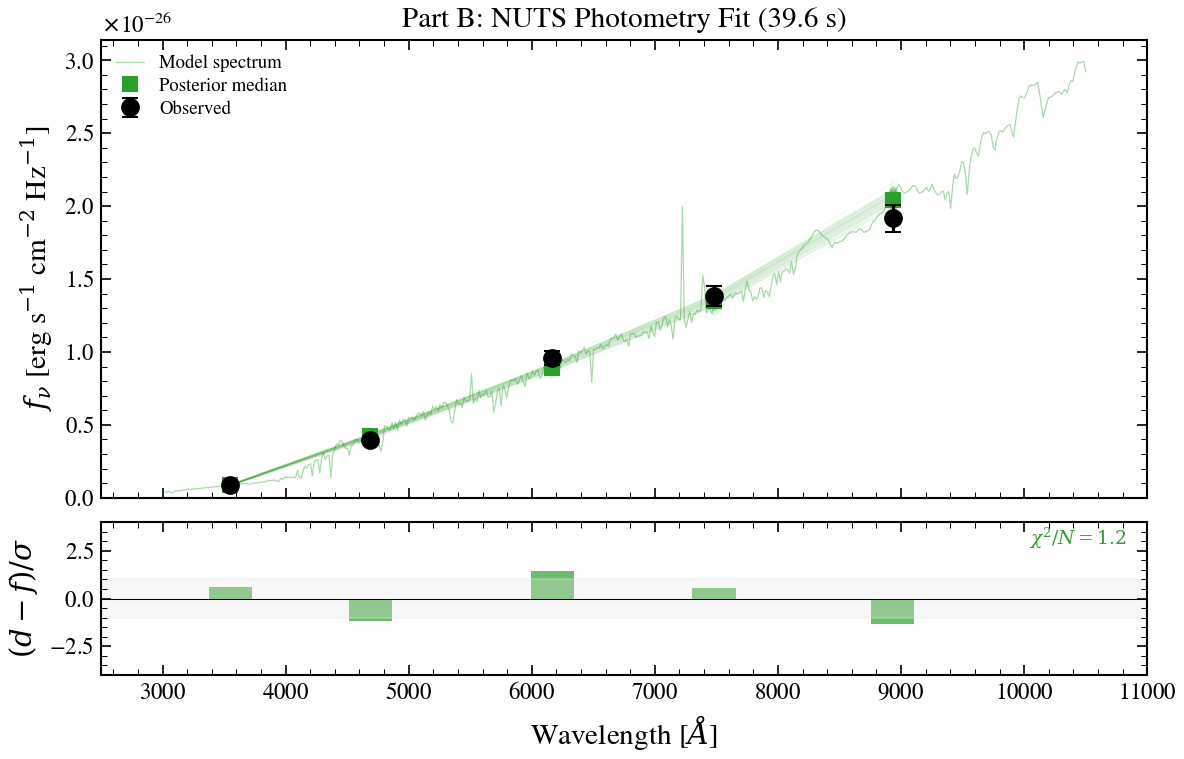

In [24]:
fig, _ = plot_phot_fit(model_stoch, mock_stoch, result_nuts_s,
                       color=COLORS["nuts"],
                       title=f"Part B: NUTS Photometry Fit ({t_nuts_s:.1f} s)")
plt.savefig("notebook_figures/000_B_nuts_phot.png", dpi=150, bbox_inches="tight")
plt.show()

### B5c. Combined SFH: Truth + EVI + NUTS

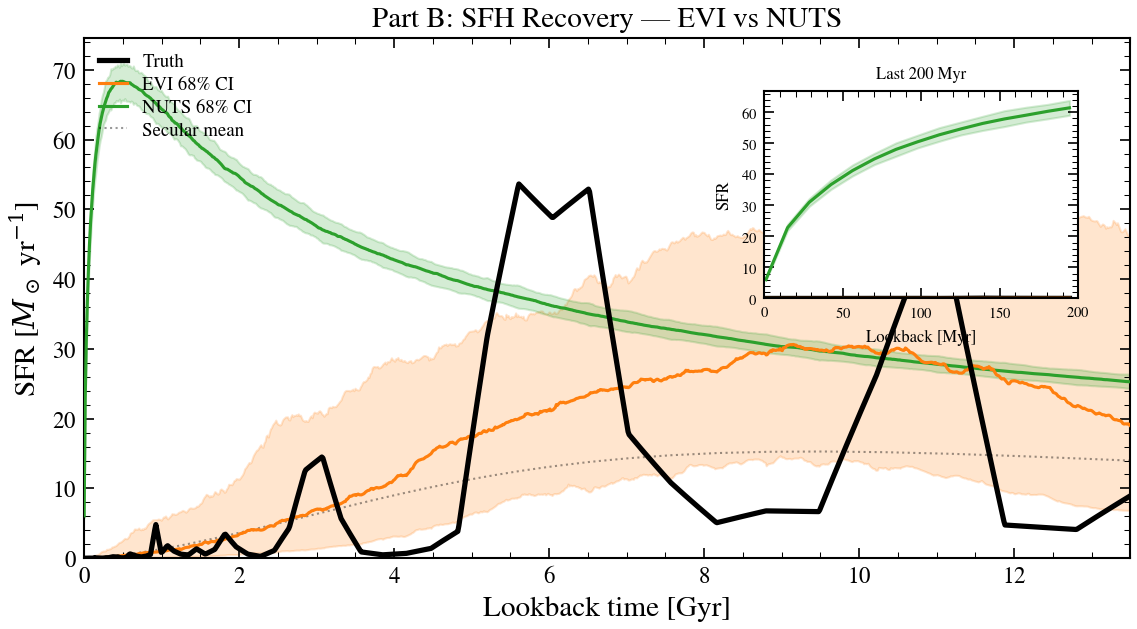

In [25]:
lo_nuts_s, med_nuts_s, hi_nuts_s = compute_sfh_band(model_stoch, result_nuts_s)

fig = plot_sfh_with_inset(
    t_gyr_s,
    sfr_list=[
        (sfr_true_s,),
        (lo_evi_s, med_evi_s, hi_evi_s),
        (lo_nuts_s, med_nuts_s, hi_nuts_s),
    ],
    labels=["Truth", "EVI 68% CI", "NUTS 68% CI"],
    colors=["k", COLORS["geovi"], COLORS["nuts"]],
    styles=[{"lw": 2.5, "zorder": 10}, {"zorder": 5}, {"zorder": 4}],
    title="Part B: SFH Recovery — EVI vs NUTS",
    sfr_mean=sfr_mean_s,
)
plt.savefig("notebook_figures/000_B_combined_sfh.png", dpi=150, bbox_inches="tight")
plt.show()

### B5d. Combined Posterior: EVI + NUTS Overlaid

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

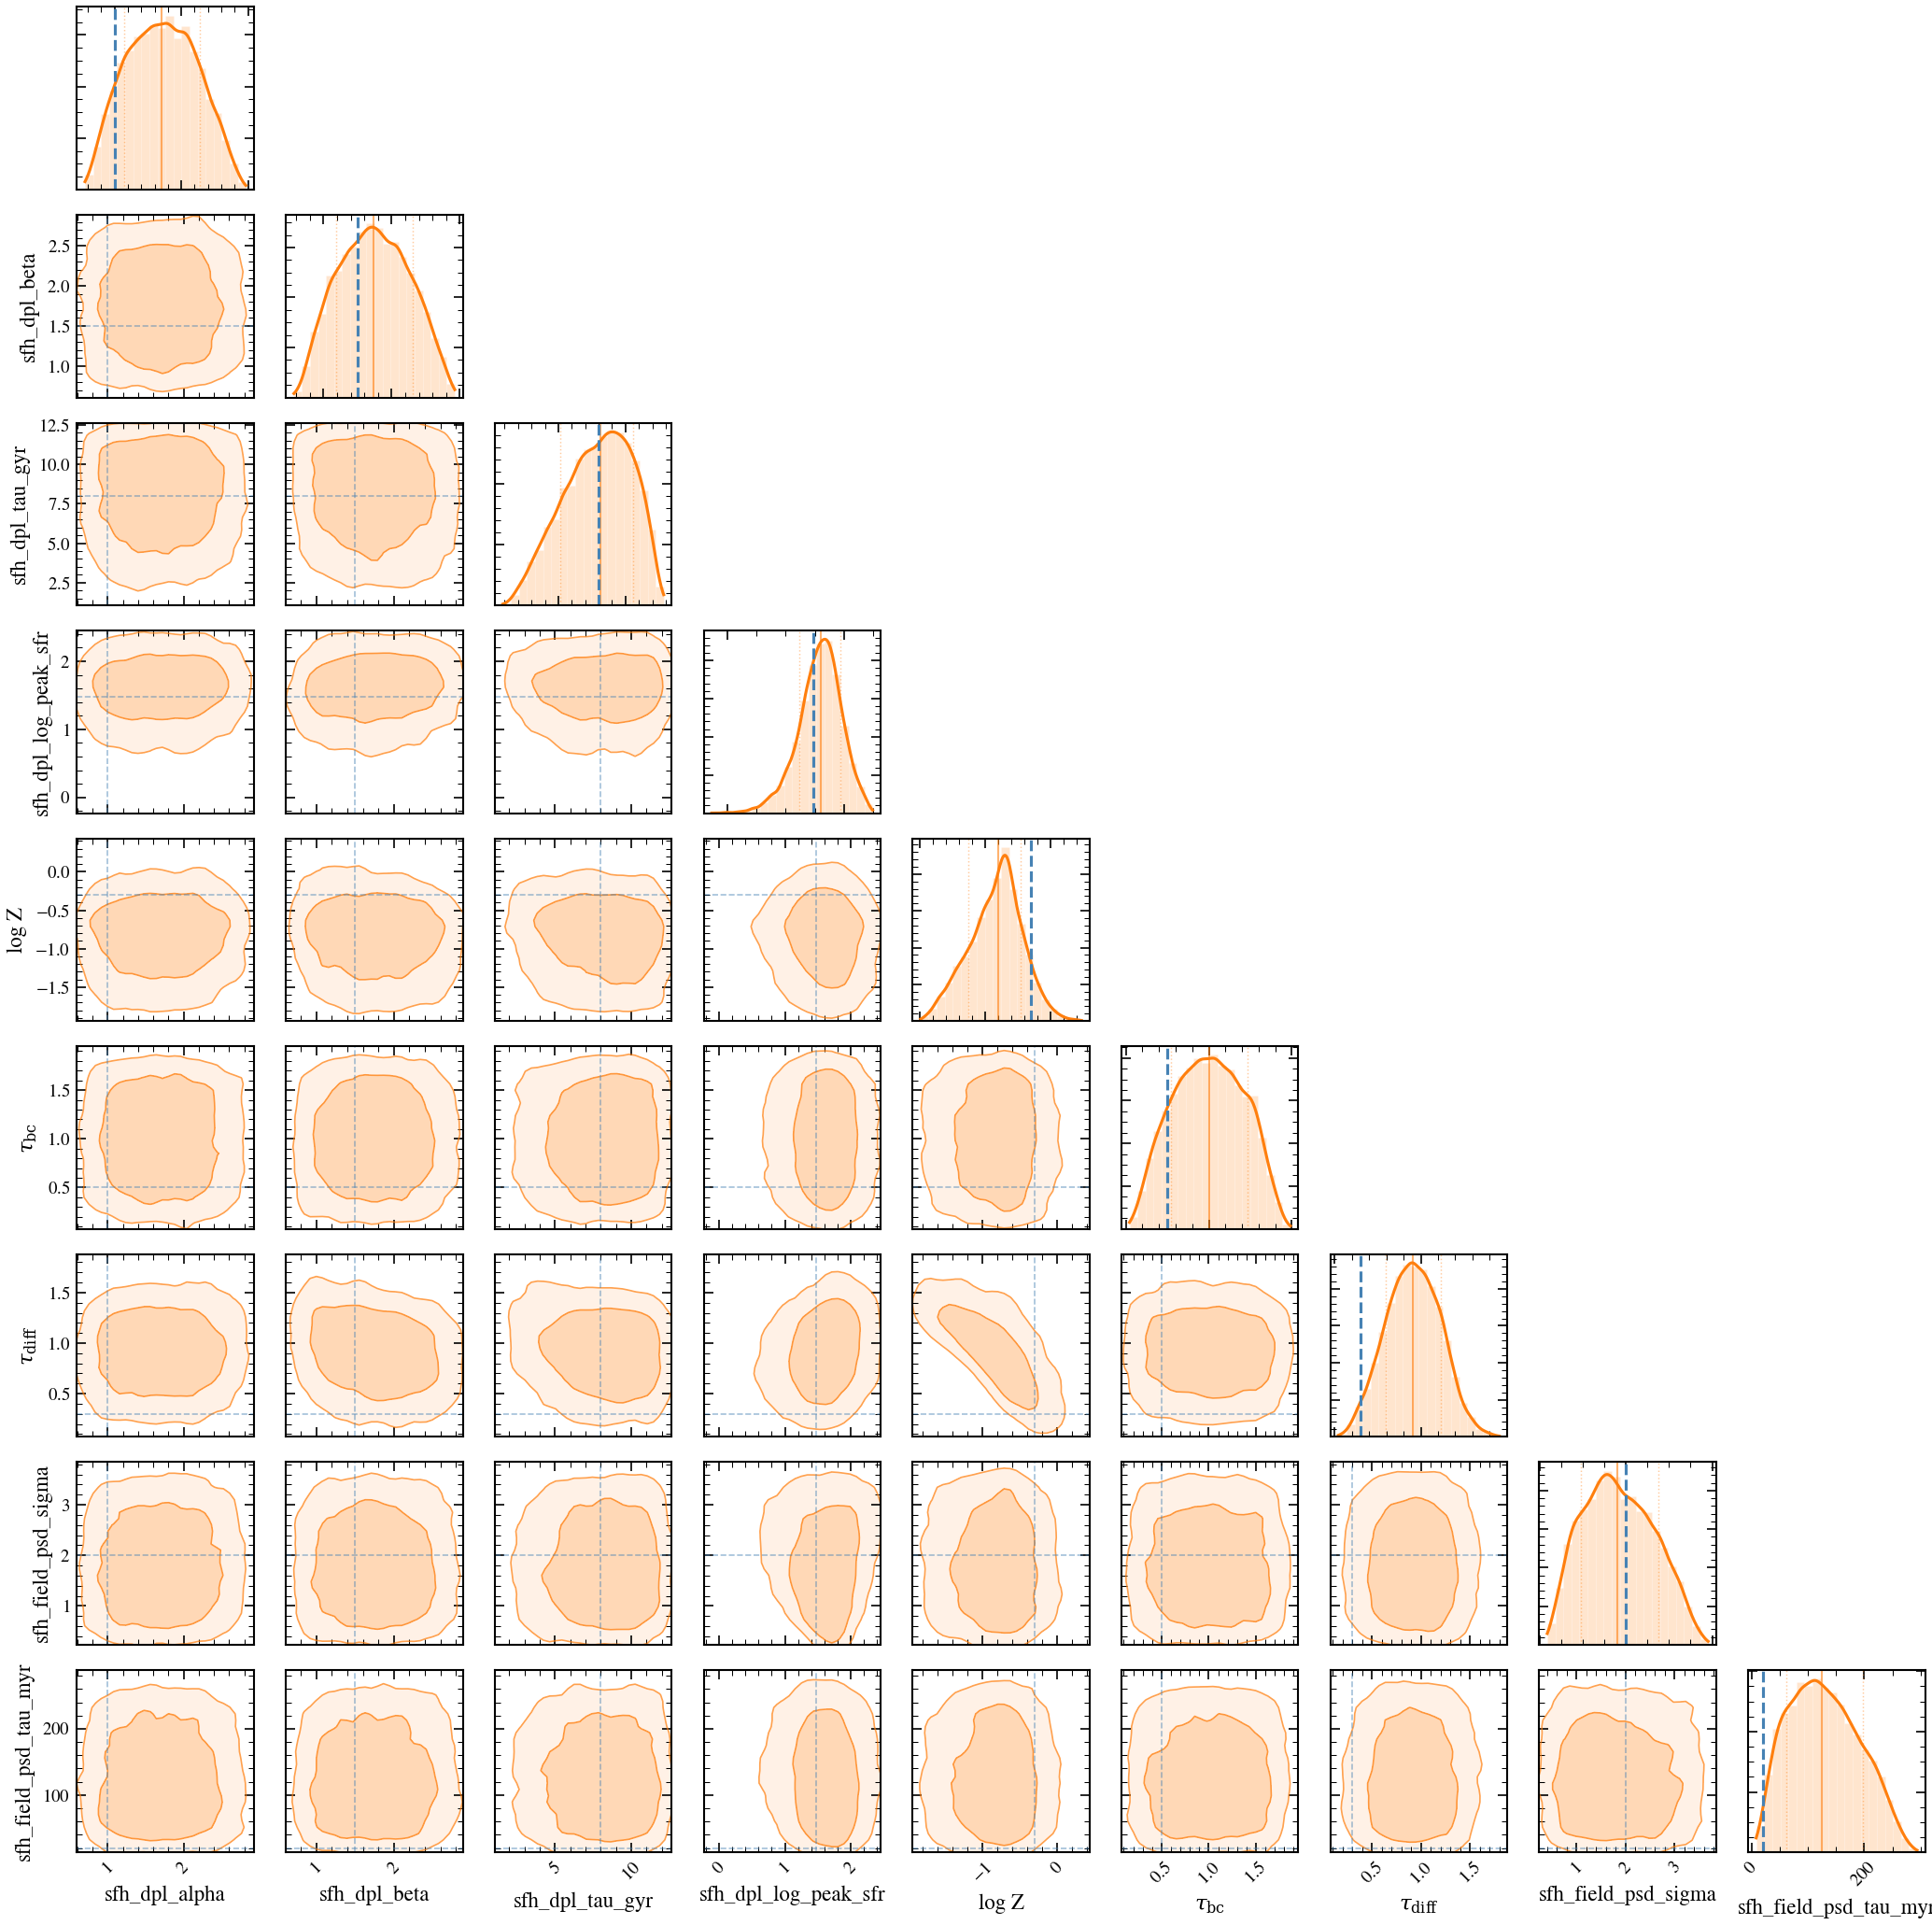

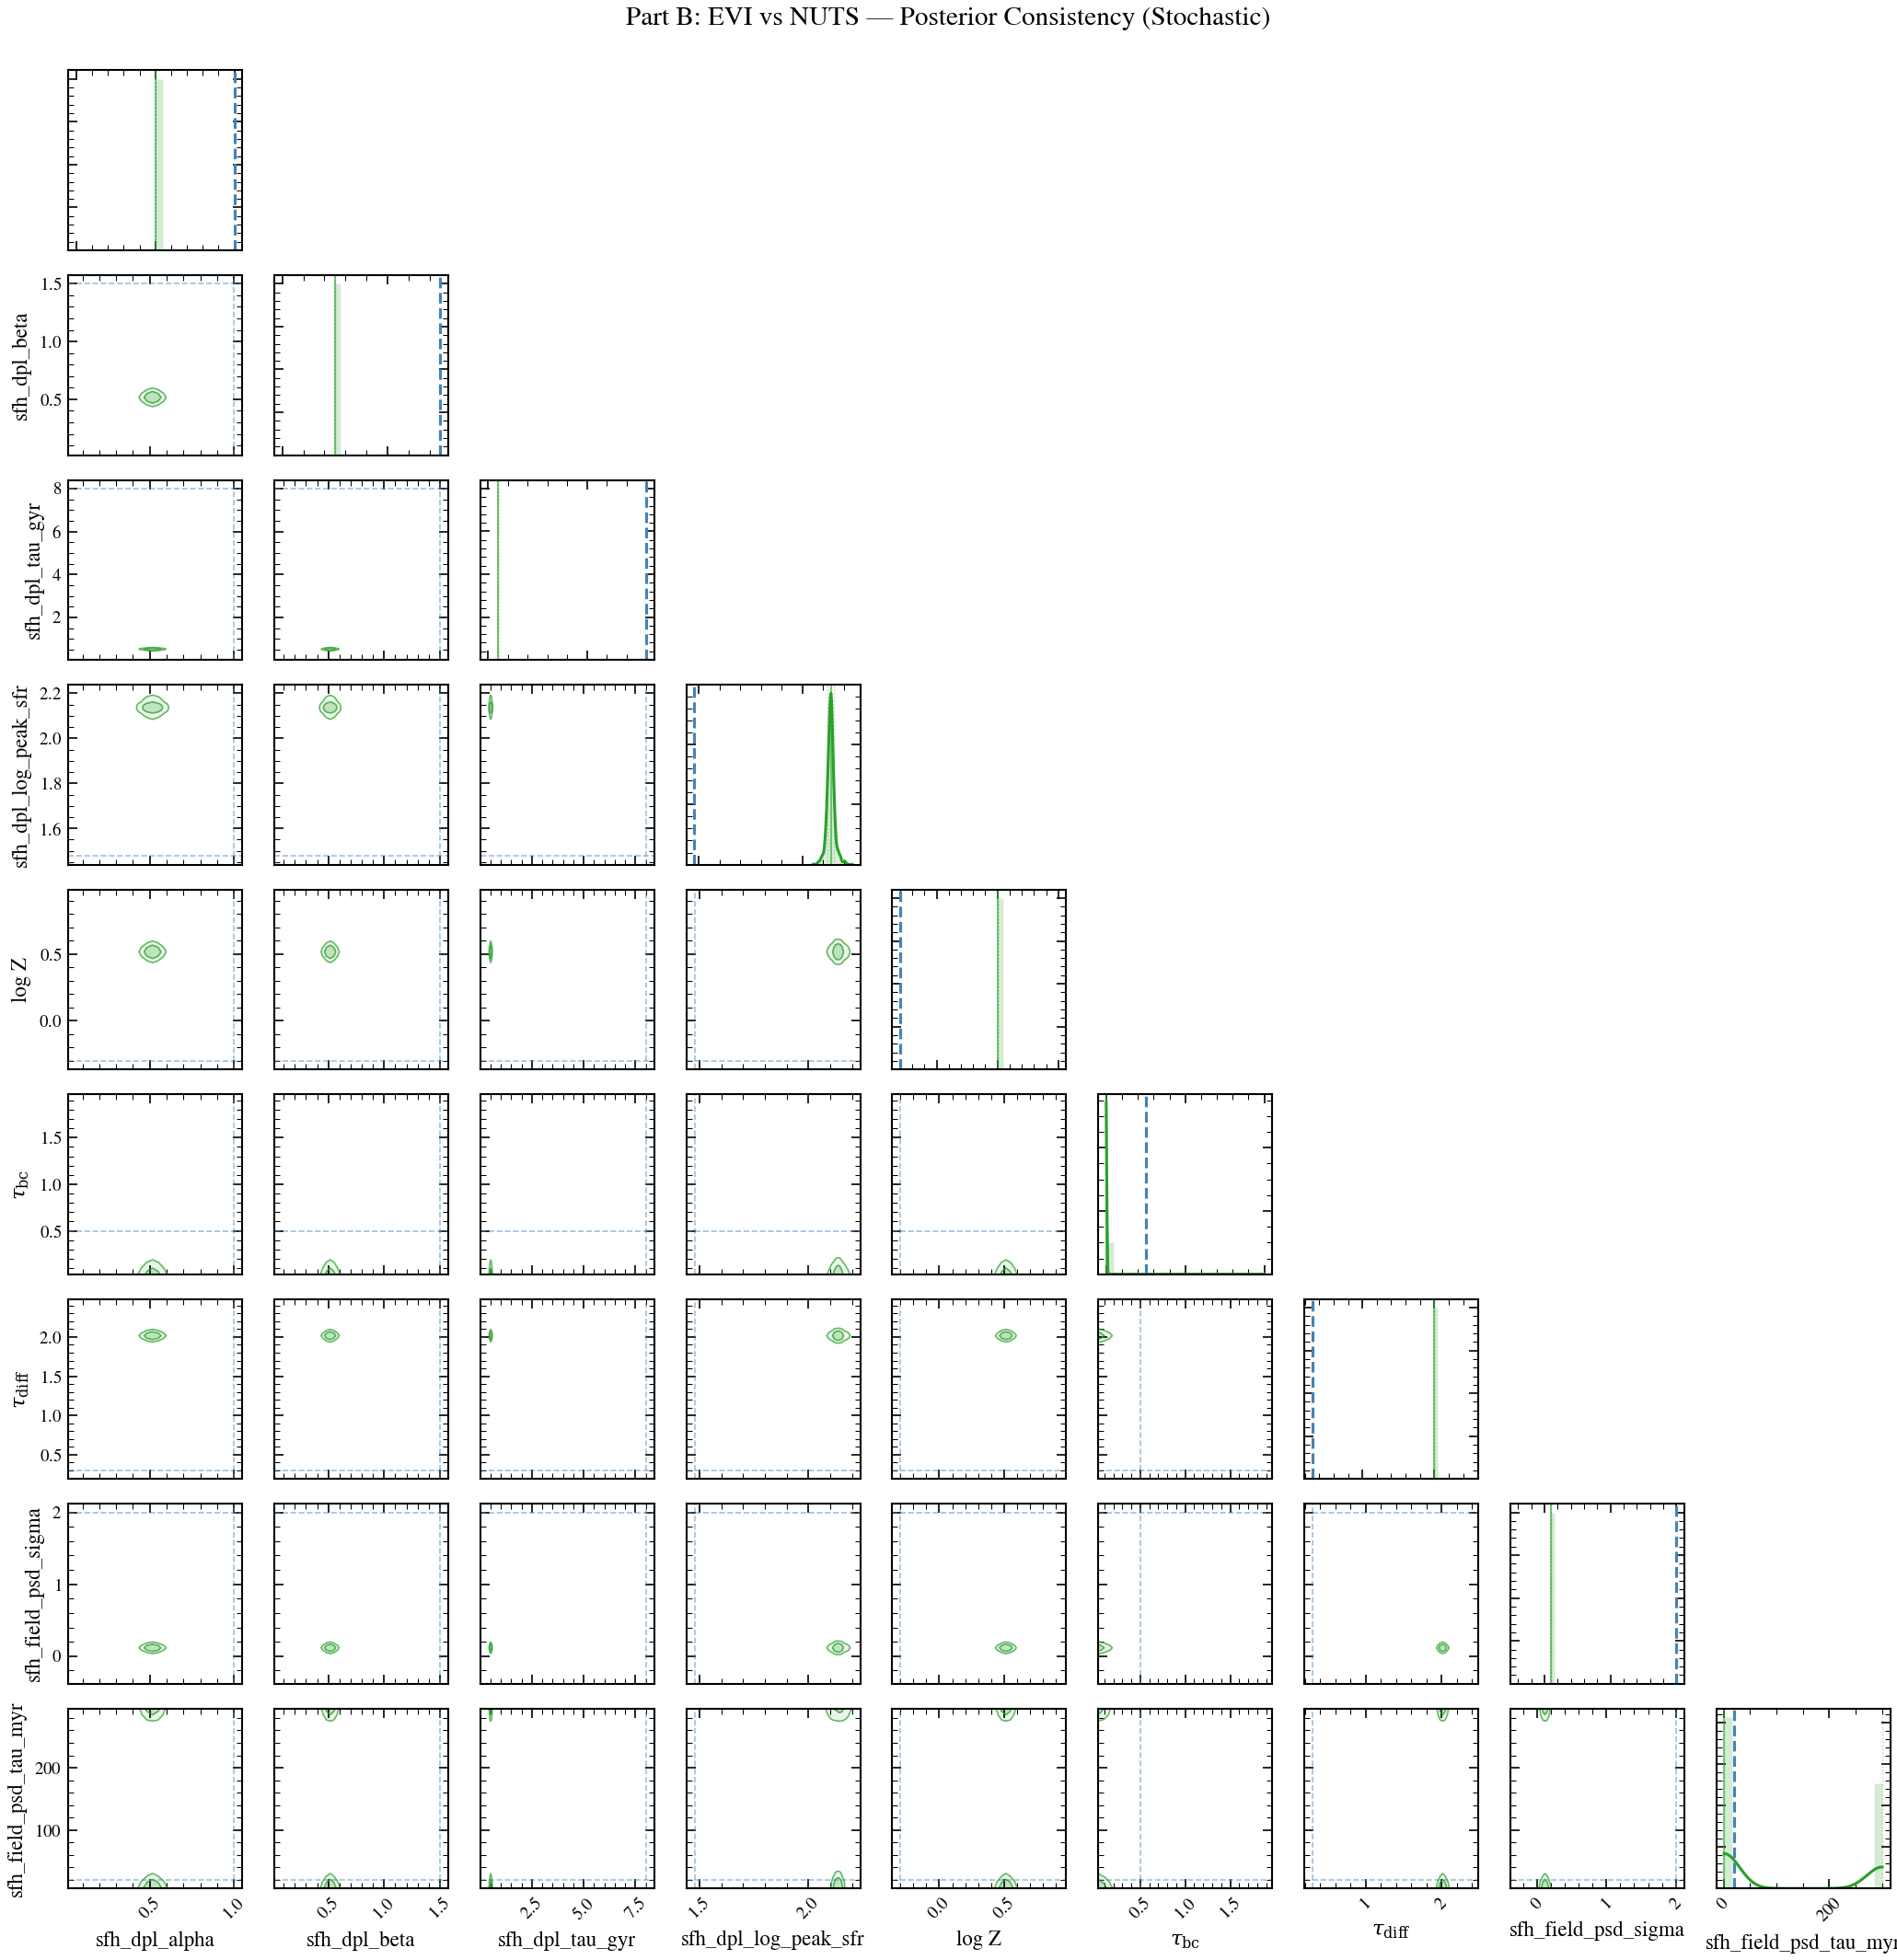

In [26]:
fig = plot_corner_comparison(
    [result_evi_s, result_nuts_s],
    ["EVI", "NUTS"],
    colors=[COLORS["geovi"], COLORS["nuts"]],
    truths=true_params_stoch,
    params=PHYS_PARAMS_STOCH,
)
make_truth_lines_red(fig)
if fig is not None:
    fig.suptitle("Part B: EVI vs NUTS — Posterior Consistency (Stochastic)",
                 y=1.02, fontsize=14)
    plt.savefig("notebook_figures/000_B_combined_corner.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## Summary

| | Part A (Parametric, $D=7$) | Part B (Stochastic, $D \approx 137$) |
|---|---|---|
| **EVI** | Fast, consistent with NUTS | Fast, primary method |
| **NUTS** | Gold standard, exact | Expensive, may diverge |
| **Agreement** | Contours overlap | Contours overlap where NUTS converges |